In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, "/home/nboley/src/fragmentomics_tools/projects/")

In [3]:
import os

import pandas as pd
import seaborn

from fragments_h5 import FragmentsH5

from fragmentomics_tools.dataframe import Region, RegionDataFrame, SampleAndRegionDataFrame
from fragmentomics_tools.fragment_array import RegionFragmentArray, SparseIntVector, merge_fragment_arrays
from fragmentomics_tools.bias_correction.train import build_promoter_rdfs

from ibd.lib import load_ibd_sample_df, build_marker_gene_rdf

# Build Gene Sets

In [4]:
def build_marker_gene_rdf(genes_rdf):
    marker_genes = pd.read_table(
        "/scratch/karius/reference/markers.immune_vs_epithelial.tsv", sep=" "
    )
    up_marker_genes = marker_genes.query("p_val_adj < 0.01 and avg_log2FC < -3").assign(
        direction="up_in_colon"
    )
    down_marker_genes = marker_genes.query(
        "p_val_adj < 0.01 and avg_log2FC > 7"
    ).assign(direction="down_in_colon")
    marker_genes = pd.concat([up_marker_genes, down_marker_genes])
    return (
        genes_rdf.set_index("gene_name")
        .join(marker_genes, how="inner")
        .reset_index()
        .reset_index(drop=True)
    )  # .query("direction == 'up_in_colon' and expression < 0.2")


def build_gene_rdfs():
    hge_raw = HematopoieticGeneExpression.load().expand_regions(2048, 2048)
    test_rdf = build_marker_gene_rdf(hge_raw)
    non_test_rdf = hge_raw.query(
        "expression < 0.1 and gene_name not in @test_rdf.gene_name"
    ).sample(frac=1.0, random_state=1337)
    train_rdf = non_test_rdf.head(3800)
    val_rdf = non_test_rdf.tail(200)
    return train_rdf, val_rdf, test_rdf


# Samples

In [5]:
sdf = load_ibd_sample_df()

In [6]:
sdf

,sample_id,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER
365,RD-36403,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_4
364,RD-36402,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_8
337,RD-36063,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_8
338,RD-36064,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_4
339,RD-36065,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_7
...,...,...,...,...,...,...,...
320,RD-50565,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 1,Site_13
321,RD-50591,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 1,Site_13
322,RD-50592,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 2,Site_16
333,RD-56149,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 6,Site_7


# TSS Sites

In [7]:
train_rdf, val_rdf, test_rdf, remaining_rdf = build_promoter_rdfs()
train_rdf.shape, val_rdf.shape, test_rdf.shape

((2108, 7), (111, 7), (1099, 12))

In [8]:
remaining_rdf

,gene_name,gene_id,contig,strand,start,stop,expression
16061,NDUFB6,ENSG00000165264,chr9,-,32572135,32574183,235.975275
9532,STARD7,ENSG00000084090,chr2,-,96207803,96209851,131.040915
14989,ARPC1A,ENSG00000241685,chr7,+,99324874,99326922,103.910747
295,PAQR7,ENSG00000182749,chr1,-,25862837,25864885,10.423316
15916,ZNF623,ENSG00000183309,chr8,+,143634995,143637043,6.210911
...,...,...,...,...,...,...,...
6164,ORAI3,ENSG00000175938,chr16,+,30948044,30950092,69.655761
5209,GSKIP,ENSG00000100744,chr14,+,96378664,96380712,25.489491
15441,C8orf48,ENSG00000164743,chr8,+,13565845,13567893,1.067162
2314,SMNDC1,ENSG00000119953,chr10,-,110303673,110305721,57.332725


In [189]:
from fragmentomics_tools.plot.tracks import Tracks, VectorTrack
from fragmentomics_tools.bias_correction.model import BackgroundModelModule
from fragmentomics_tools.bias_correction.data import build_counts
from tqdm import tqdm

def index_key_to_track_name(args):
    strand, fl, coverage_type = args
    return f"strand_{strand}__fl_{fl[0]}_{fl[1]}__coverage_{coverage_type}"

def normalize(_dist, _cnts):
    weights = _dist.mean()/_dist.mean().mean()
    return _cnts.todense()/weights

def make_counts_df(rdf, sdf, model):
    # work around jupyter display bug
    tqdm._instances.clear()

    # pred the background
    print("Predicting background dists (1/5)")
    pred = model.predict_from_rdf(rdf.set_index("gene_name"))
    count_columns = [x[len("pred_dist."):] for x in pred.columns if x.startswith("pred_dist.")]

    # get the fragment arrays
    print("Loading fragment arrays (2/5)")
    srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(rdf.query("strand == '+'"), sdf).attach_fragment_arrays(num_cores=24)

    # build the coverage counts
    print("Building Coverage Counts (3/5)")
    counts = srdf.parallel_apply(lambda rec: rec.fragment_array.build_coverage_counts(fl_bands=[(40, 65), (120, 175)], return_sparse=True), n_workers=24)
    counts.columns = [index_key_to_track_name(x) for x in counts.columns]
    srdf = srdf.join(counts)

    # join the observed counts to the predicted densities
    print("Attach and aggregate over observed counts (4/5)")
    df = pred.join(srdf.df[["gene_name"] + count_columns].dropna(), how='inner')
    # df = pred.join(srdf.df[["gene_name"] + count_columns].dropna().groupby(by=["gene_name"]).sum(), how='inner')

    # attach the normalized columns
    print("build normalized columns (5/5)")
    normalized = []
    for column in tqdm(count_columns): 
        normalized.append(df[['pred_dist.' + column, column]].apply(lambda record: normalize(record['pred_dist.' + column], record[column]), axis=1).rename("normalized." + column))
    df = df.join(pd.concat(normalized, axis=1))

    return df, srdf

def make_tracks_for_counts_df(sub_df, smooth = True, smooth_win_len = 5):
    tracks = Tracks()
    
    for column_template in ["strand_{}__fl_40_65__coverage_first", "strand_{}__fl_120_175__coverage_midpoint"]:
        tracks.append((
            VectorTrack(sub_df['pred_dist.' + column_template.format("-")].apply(lambda x: x.mean()).sum()/len(sub_df), color='green', smooth=smooth, smooth_window_len=smooth_win_len) \
            + VectorTrack(sub_df['pred_dist.' + column_template.format("+")].apply(lambda x: x.mean()).sum()/len(sub_df), smooth=smooth, smooth_window_len=smooth_win_len)
        ))
        tracks.append((
            VectorTrack(SparseIntVector.sum(sub_df[column_template.format("-")]).todense(), color='green', smooth=smooth, smooth_window_len=smooth_win_len) \
            + VectorTrack(SparseIntVector.sum(sub_df[column_template.format("+")]).todense(), smooth=smooth, smooth_window_len=smooth_win_len)
        ))
        tracks.append((
            VectorTrack(sub_df['normalized.' + column_template.format("-")].sum()/len(sub_df), color='green', smooth=smooth, smooth_window_len=smooth_win_len) \
            + VectorTrack(sub_df['normalized.' + column_template.format("+")].sum()/len(sub_df), smooth=smooth, smooth_window_len=smooth_win_len)
        ))
    return tracks

def make_tracks_for_pred(sub_df, smooth = False, smooth_win_len = 5):
    tracks = Tracks()
    
    for column_template in ["strand_{}__fl_40_65__coverage_first", "strand_{}__fl_120_175__coverage_midpoint"]:
        tracks.append((
            VectorTrack(sub_df['pred_dist.' + column_template.format("-")].apply(lambda x: x.mean()).sum()/len(sub_df), color='green', smooth=smooth, smooth_window_len=smooth_win_len) \
            + VectorTrack(sub_df['pred_dist.' + column_template.format("+")].apply(lambda x: x.mean()).sum()/len(sub_df), smooth=smooth, smooth_window_len=smooth_win_len)
        ))
    return tracks

In [171]:
model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/tss_model/merged.off_promoters.multinomial.5.res').cuda()
pred = model.predict_from_rdf(remaining_rdf.query("strand == '+'").set_index("gene_name"))
count_columns = [x[len("pred_dist."):] for x in pred.columns if x.startswith("pred_dist.")]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3521/3521 [00:06<00:00, 514.01it/s]


(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='NA'>])

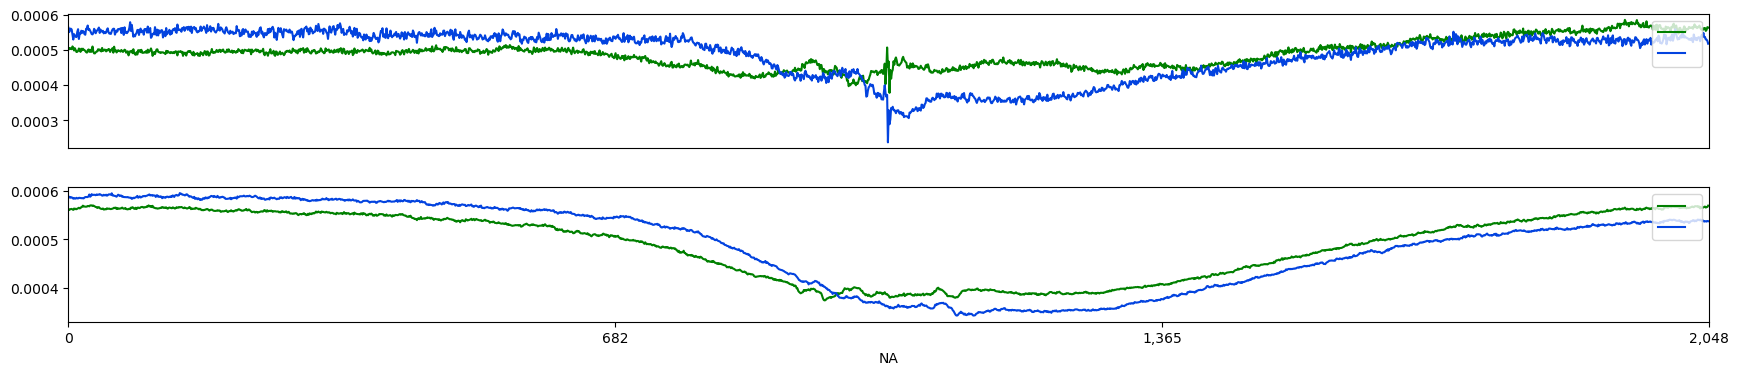

In [174]:
make_tracks_for_pred(pred).plot()

(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='NA'>])

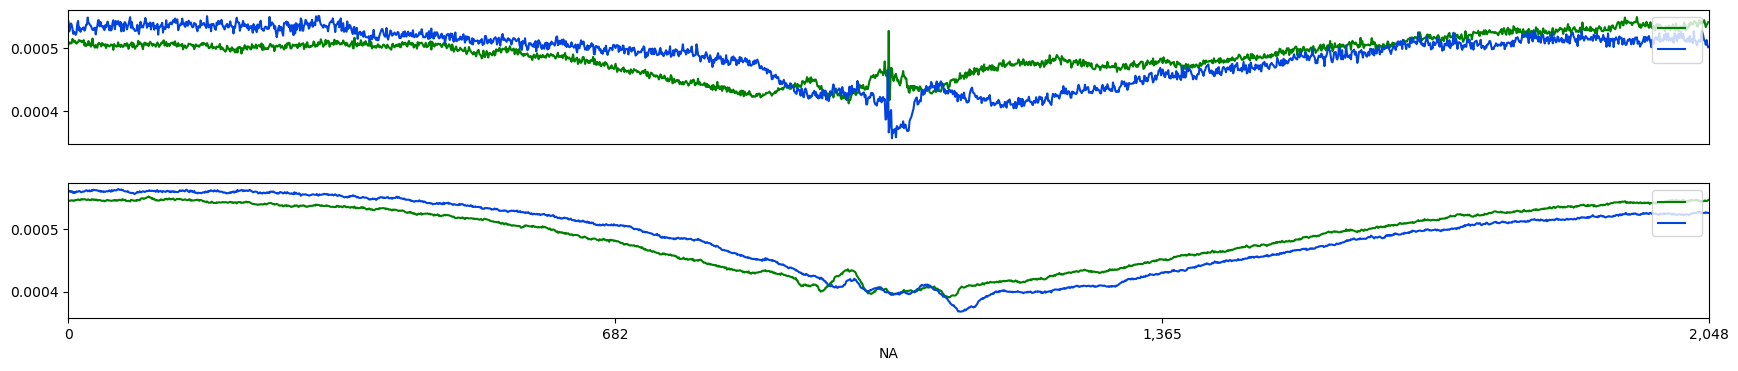

In [151]:
make_tracks_for_pred(pred).plot()

In [1]:
model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/tss_model/merged.off_promoters.multinomial.2.res').cuda()
train_df, train_srdf = make_counts_df(train_rdf.head(100), sdf.query('label == 1'), model)

NameError: name 'BackgroundModelModule' is not defined

(<Figure size 2500x1200 with 6 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='NA'>])

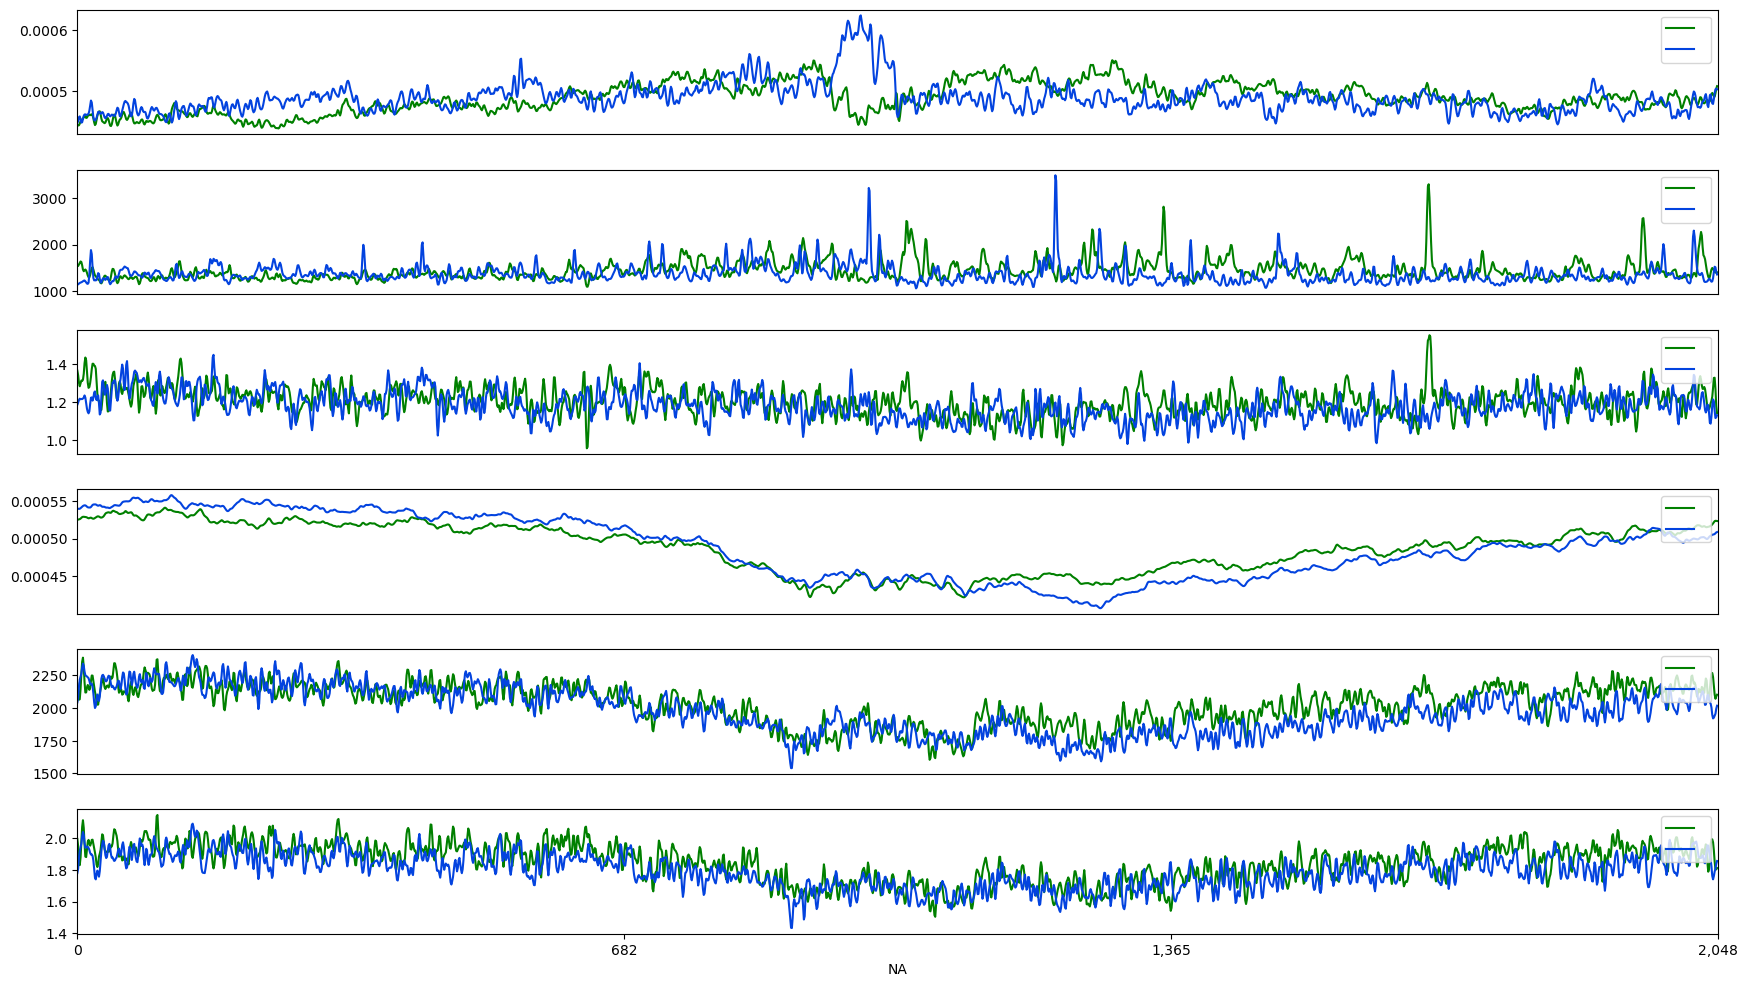

In [74]:
make_tracks_for_counts_df(train_df).plot()

In [42]:
model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/tss_model/merged.off_promoters.multinomial.2.res').cuda()
df = make_counts_df(remaining_rdf, sdf.query('label == 1'), model)

Predicting background dists (1/5)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7120/7120 [00:11<00:00, 631.26it/s]


Loading fragment arrays (2/5)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 359142/359142 [05:04<00:00, 1178.56it/s]


Building Coverage Counts (3/5)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 359142/359142 [02:05<00:00, 2863.45it/s]


Attach and aggregate over observed counts (4/5)
build normalized columns (5/5)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:02<00:00,  5.54it/s]


In [57]:
x = df['pred_dist.strand_+__fl_40_65__coverage_first'].apply(lambda x: x.mean()).sum()
y = df['strand_+__fl_40_65__coverage_first'].apply(lambda x: x.todense()).sum()

<Axes: xlabel='x', ylabel='y'>

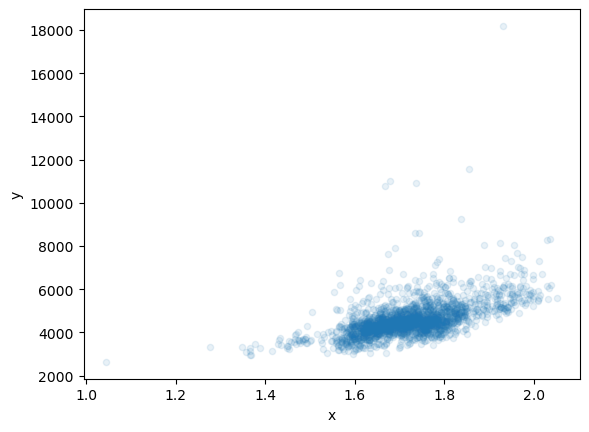

In [63]:
pd.DataFrame(dict(x=x, y=y)).plot.scatter(x='x', y='y', alpha=0.1)

(<Figure size 2500x1200 with 6 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='NA'>])

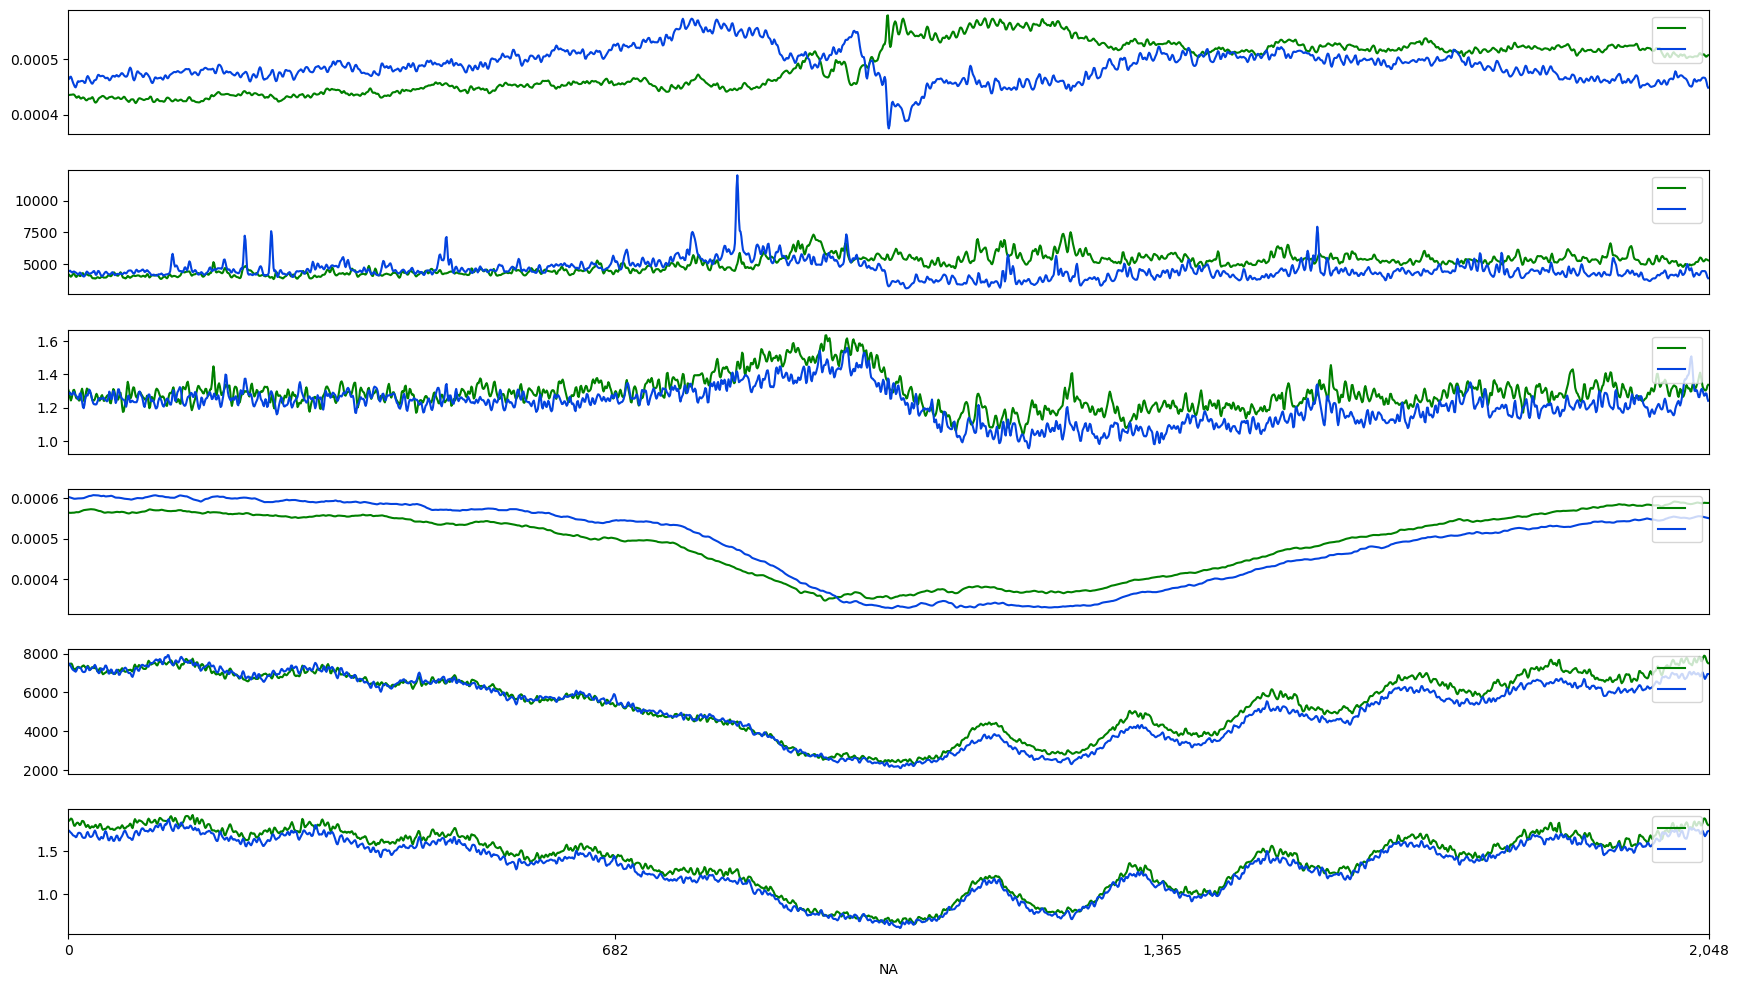

In [43]:
make_tracks_for_counts_df(df).plot()

In [136]:
model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/tss_model/merged.off_promoters.multinomial.2.res').cuda()
df_test, srdf_test = make_counts_df(test_rdf.query("avg_log2FC > 0"), sdf, model)

Predicting background dists (1/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 624/624 [00:00<00:00, 910.82it/s]


Loading fragment arrays (2/5)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 92415/92415 [01:13<00:00, 1265.81it/s]


Building Coverage Counts (3/5)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 92415/92415 [00:38<00:00, 2410.30it/s]


Attach and aggregate over observed counts (4/5)
build normalized columns (5/5)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 41.99it/s]


In [181]:
def score(record):
    fwd_post = record.loc[:, 'strand_+__fl_40_65__coverage_first'].sum().todense()[1024:1024+512].sum()
    bkwd_post = record.loc[:, 'strand_-__fl_40_65__coverage_first'].sum().todense()[1024:1024+512].sum()

    fwd_pre = record.loc[:, 'strand_+__fl_40_65__coverage_first'].sum().todense()[1024-512:1024].sum()
    bkwd_pre = record.loc[:, 'strand_-__fl_40_65__coverage_first'].sum().todense()[1024-512:1024].sum()
    return pd.Series(dict(a=(bkwd_post-fwd_post) - (bkwd_pre-fwd_pre)))

tmp = srdf_test.df.groupby(['gene_name', 'sample_id', 'label'], axis=0).apply(score) # .iloc[:, )

WARNING	2024-04-22 14:12:16,655	/tmp/ipykernel_471198/890820623.py:9: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  tmp = srdf_test.df.groupby(['gene_name', 'sample_id', 'label'], axis=0).apply(score) # .iloc[:, )

WARNING	2024-04-22 14:12:54,715	/tmp/ipykernel_471198/890820623.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = srdf_test.df.groupby(['gene_name', 'sample_id', 'label'], axis=0).apply(score) # .iloc[:, )



In [183]:
tmp.reset_index()[['label', 'a']].groupby('label').mean() # .plot.box(by='label')

,a
label,
0,0.297737
1,2.316346
2,2.806550
3,2.513253
4,1.521952


(<Figure size 2500x1200 with 6 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='NA'>])

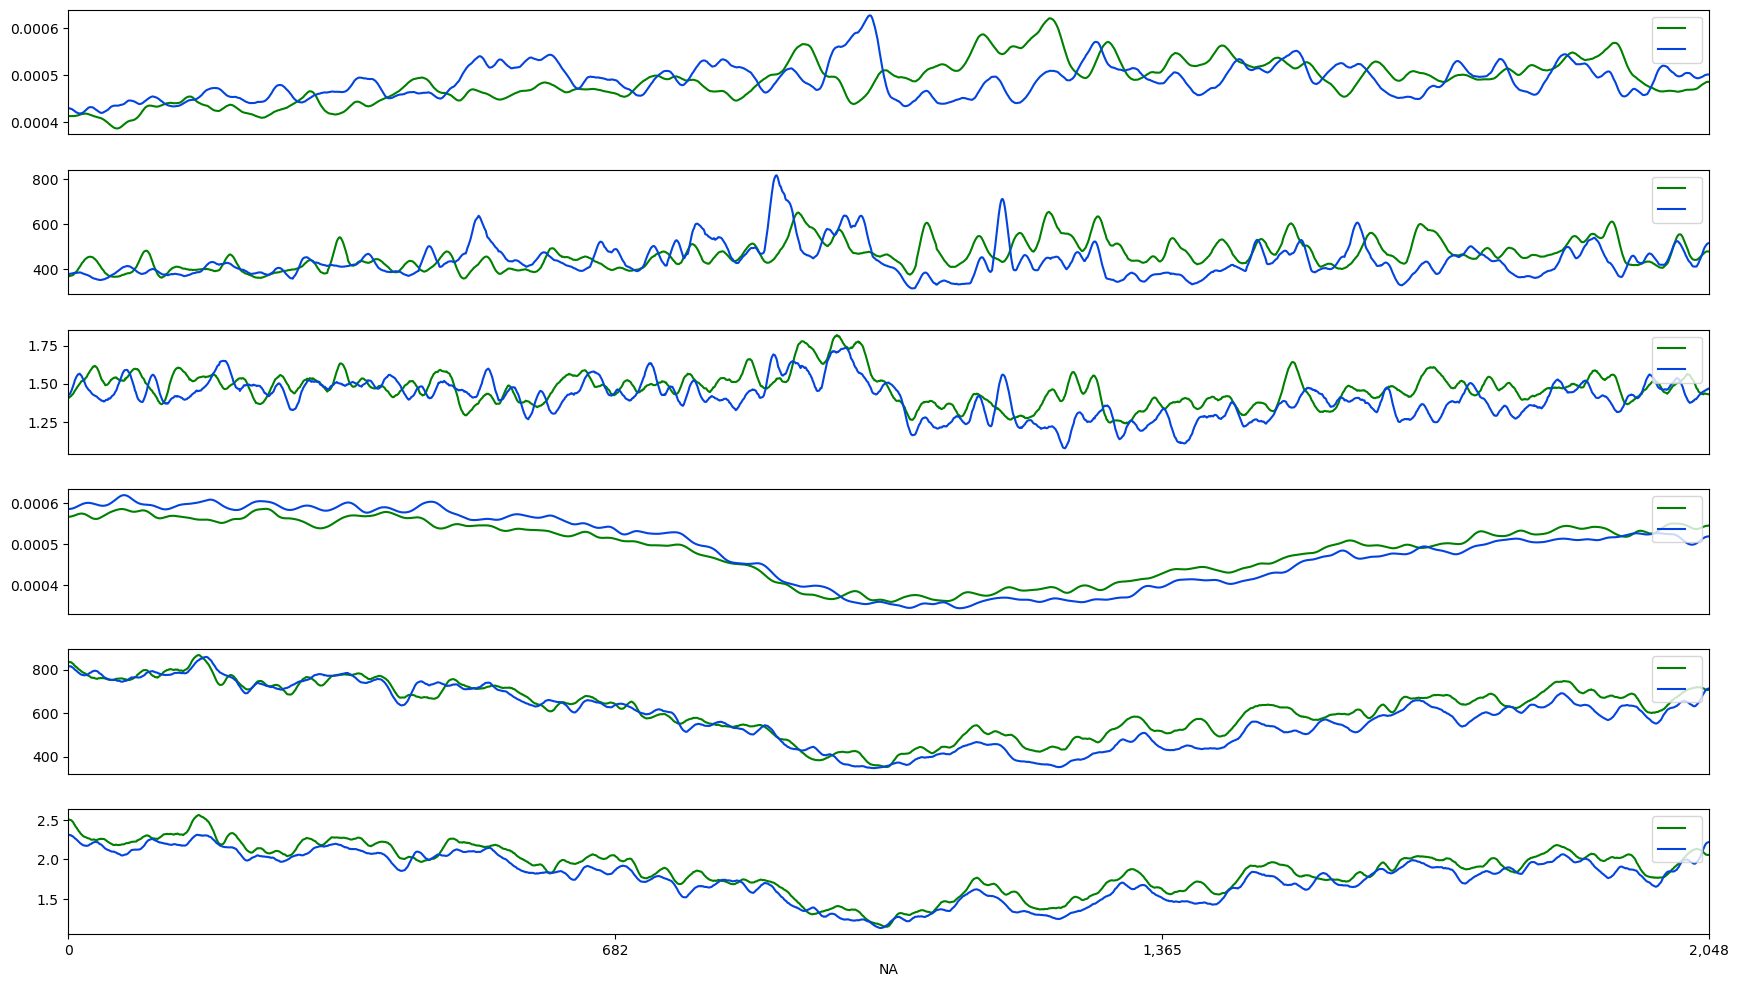

In [77]:
make_tracks_for_counts_df(df_test_4, smooth_win_len=25).plot()

In [46]:
model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/tss_model/merged.off_promoters.multinomial.2.res').cuda()
df_test_1 = make_counts_df(test_rdf.query("avg_log2FC > 0"), sdf.query('label == 1'), model)

Predicting background dists (1/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 624/624 [00:00<00:00, 905.58it/s]


Loading fragment arrays (2/5)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30906/30906 [00:24<00:00, 1238.84it/s]


Building Coverage Counts (3/5)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30906/30906 [00:17<00:00, 1770.30it/s]


Attach and aggregate over observed counts (4/5)
build normalized columns (5/5)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 56.95it/s]


(<Figure size 2500x1200 with 6 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='NA'>])

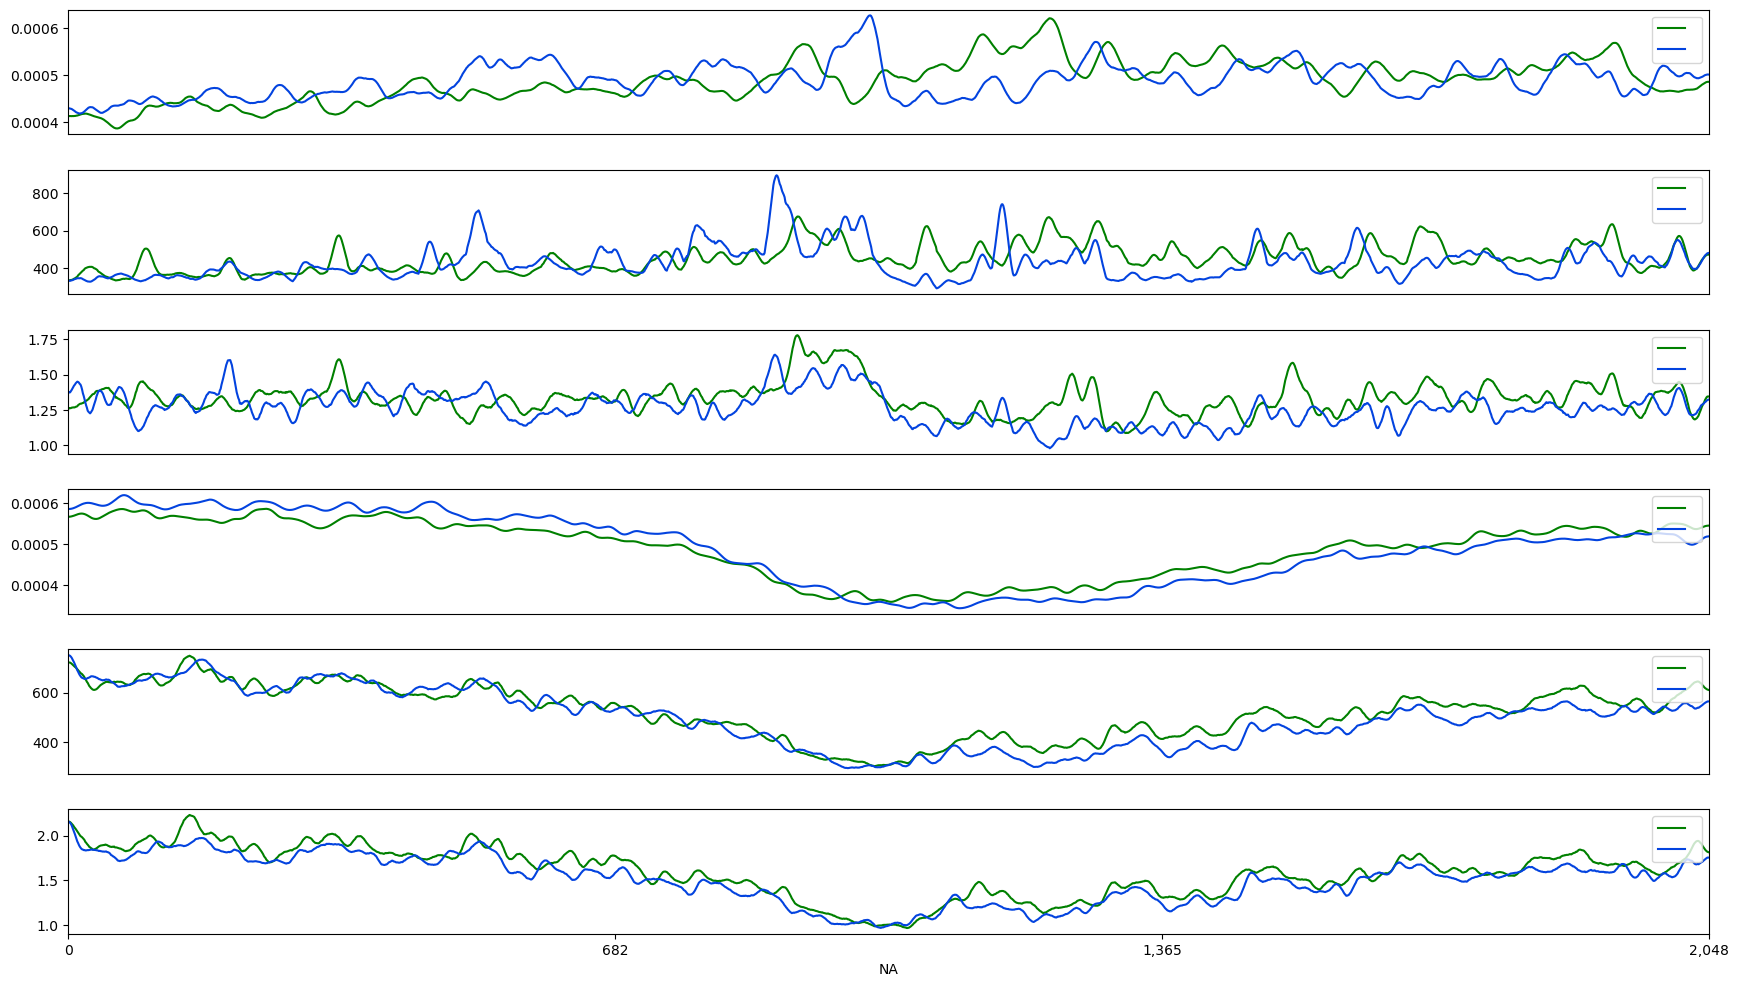

In [78]:
make_tracks_for_counts_df(df_test_1, smooth_win_len=25On in GI).plot()

(<Figure size 2500x1200 with 6 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='NA'>])

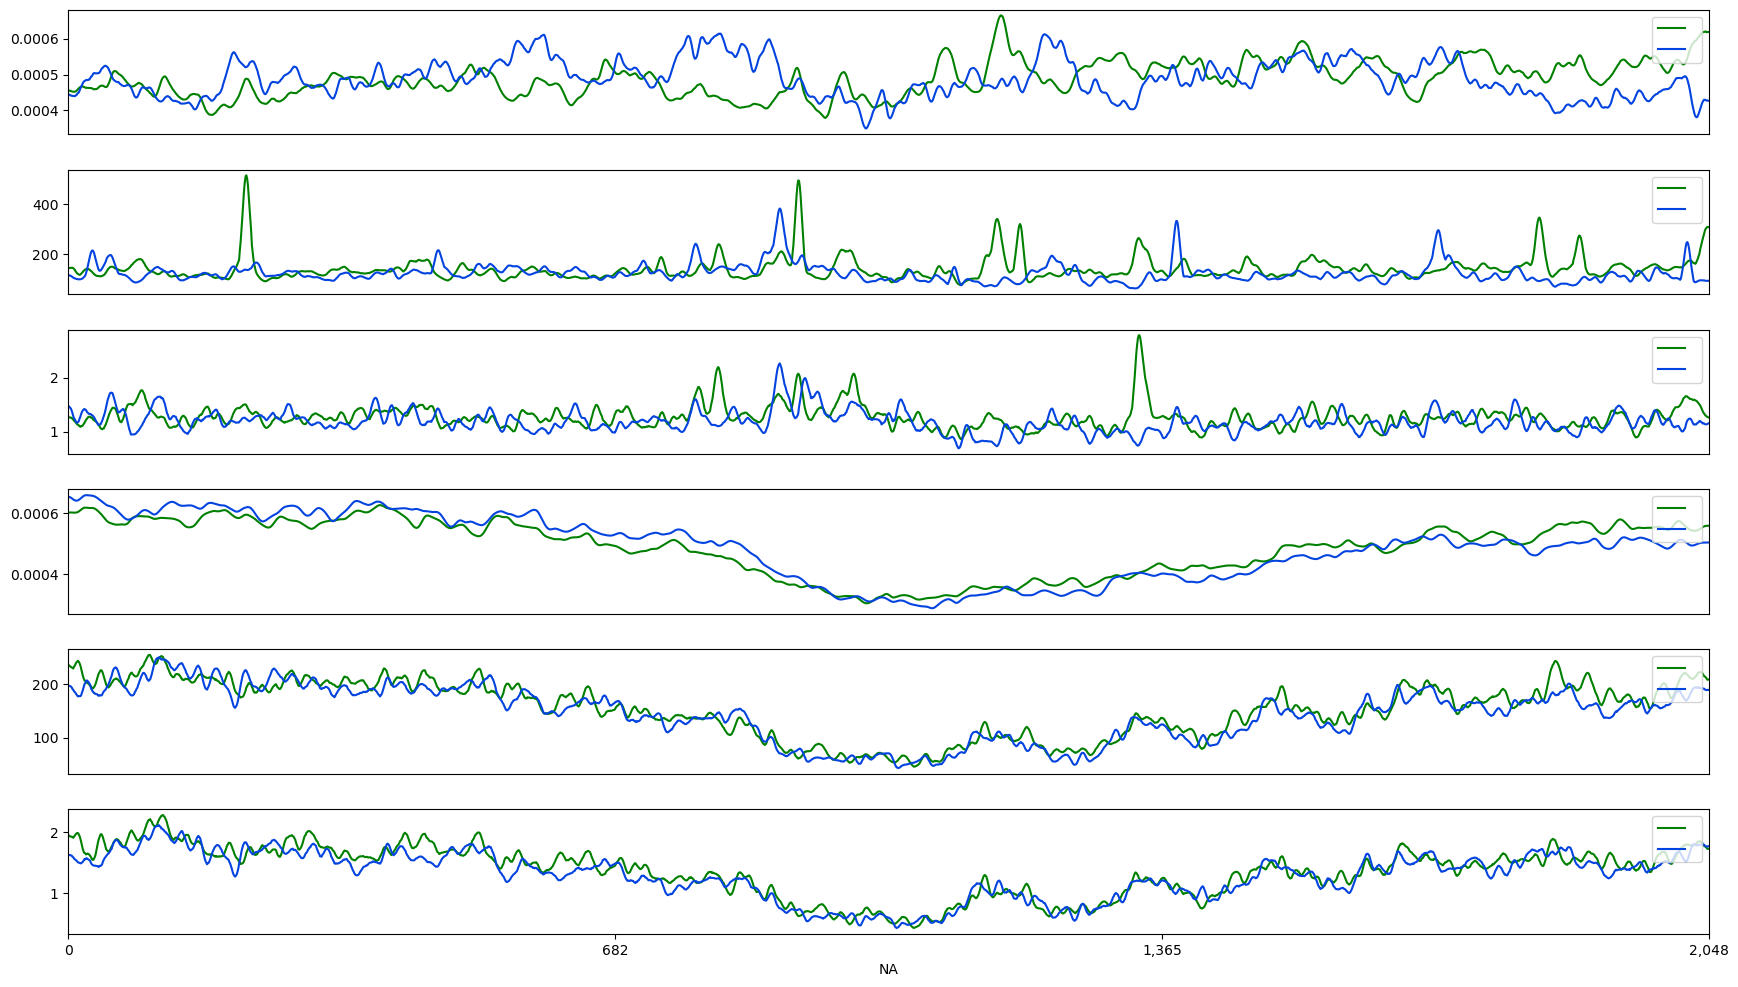

In [310]:
make_tracks_for_counts_df(df.sample(100)).plot()

In [274]:
?VectorTrack

Init signature:
VectorTrack(
    input: object = None,
    region: fragmentomics_tools.region.Region = None,
    name: str = None,
    color: str = 'xkcd:blue',
    height: int = 2,
    vlines: List[fragmentomics_tools.plot.tracks.VLine] = <factory>,
    lines: List[fragmentomics_tools.plot.tracks.Line] = <factory>,
    ylim: Tuple[Union[int, float], Union[int, float]] = None,
    legend: bool = False,
    title_color: str = None,
    title_fontweight: str = 'bold',
    alpha: float = 1.0,
    linewidth: Optional[float] = None,
    linestyle: str = '-',
    ymin: Optional[float] = None,
    ymax: Optional[float] = None,
    scale: float = 1.0,
    smooth: bool = False,
    smooth_num_std: int = 2,
    smooth_window_len: int = 15,
) -> None
Docstring:      VectorTrack(input: object = None, region: fragmentomics_tools.region.Region = None, name: str = None, color: str = 'xkcd:blue', height: int = 2, vlines: List[fragmentomics_tools.plot.tracks.VLine] = <factory>, lines: List[fragmentomic

In [61]:
remaining_rdf = RegionDataFrame(remaining_rdf.df.join(pred), ref=remaining_rdf.ref)
remaining_rdf.df

,gene_name,gene_id,contig,strand,start,stop,expression,pred_dist.strand_+__fl_40_65__coverage_first,pred_dist.strand_+__fl_40_65__coverage_last,pred_dist.strand_+__fl_40_65__coverage_midpoint,pred_dist.strand_+__fl_120_175__coverage_first,pred_dist.strand_+__fl_120_175__coverage_last,pred_dist.strand_+__fl_120_175__coverage_midpoint,pred_dist.strand_-__fl_40_65__coverage_first,pred_dist.strand_-__fl_40_65__coverage_last,pred_dist.strand_-__fl_40_65__coverage_midpoint,pred_dist.strand_-__fl_120_175__coverage_first,pred_dist.strand_-__fl_120_175__coverage_last,pred_dist.strand_-__fl_120_175__coverage_midpoint
2999,TRMT112,ENSG00000173113,chr11,-,64316534,64318582,468.271162,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
6133,TBX6,ENSG00000149922,chr16,-,30090217,30092265,1.972586,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
13076,RNF180,ENSG00000164197,chr5,+,64164819,64166867,0.195669,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
7820,TPGS1,ENSG00000141933,chr19,+,506473,508521,80.144386,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
1794,LARP4B,ENSG00000107929,chr10,-,872181,874229,46.440576,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

# On analysis

In [64]:
on_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(remaining_rdf.query("expression > 20 and strand == '+'"), sdf).attach_fragment_arrays(num_cores=24)
on_srdf['fragment_array'] = [fa.drop_duplicate_fragments() for fa in on_srdf.fragment_array]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 581025/581025 [07:47<00:00, 1242.44it/s]


In [68]:
%%time
def index_key_to_track_name(args):
    strand, fl, coverage_type = args
    return f"strand_{strand}__fl_{fl[0]}_{fl[1]}__coverage_{coverage_type}"

res = on_srdf.parallel_apply(lambda rec: rec.fragment_array.build_coverage_counts(fl_bands=[(40, 65), (120, 175)], return_sparse=True), n_workers=12)
res.columns = [index_key_to_track_name(x) for x in res.columns]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 581025/581025 [03:17<00:00, 2948.55it/s]


CPU times: user 5min 21s, sys: 17.6 s, total: 5min 39s
Wall time: 5min 39s


In [70]:
from fragmentomics_tools.plot.tracks import Tracks, VectorTrack


def make_tracks(cov, smooth=False):
    # first make the midpoint tracks
    small_mp = VectorTrack(cov['strand_+__fl_40_65__coverage_midpoint'], name='midpoint forward strand', smooth=smooth) + VectorTrack(cov['strand_-__fl_40_65__coverage_midpoint'], color='green', name='midpoint reverse strand', smooth=smooth)
    big_mp = VectorTrack(cov['strand_+__fl_120_175__coverage_midpoint'], name='midpoint forward strand', smooth=smooth) + VectorTrack(cov['strand_-__fl_120_175__coverage_midpoint'], color='green', name='midpoint reverse strand', smooth=smooth)
    
    small_left = VectorTrack(cov['strand_+__fl_40_65__coverage_first'], name='first forward strand', smooth=smooth) + VectorTrack(cov['strand_-__fl_40_65__coverage_first'], color='green', name='first reverse strand', smooth=smooth)
    big_left = VectorTrack(cov['strand_+__fl_120_175__coverage_first'], name='first forward strand', smooth=smooth) + VectorTrack(cov['strand_-__fl_120_175__coverage_first'], color='green', name='first reverse strand', smooth=smooth)

    small_right = VectorTrack(cov['strand_+__fl_40_65__coverage_last'], name='last forward strand', smooth=smooth) + VectorTrack(cov['strand_-__fl_40_65__coverage_last'], color='green', name='last reverse strand', smooth=smooth)
    big_right = VectorTrack(cov['strand_+__fl_120_175__coverage_last'], name='last forward strand', smooth=smooth) + VectorTrack(cov['strand_-__fl_120_175__coverage_last'], color='green', name='last reverse strand', smooth=smooth)

    tracks = Tracks([small_left])
    return tracks
    for c in cov.index:
        tracks.append(VectorTrack(cov[c], name=c, smooth=False))
    return tracks

In [69]:
res

,strand_+__fl_40_65__coverage_first,strand_+__fl_40_65__coverage_last,strand_+__fl_40_65__coverage_midpoint,strand_+__fl_120_175__coverage_first,strand_+__fl_120_175__coverage_last,strand_+__fl_120_175__coverage_midpoint,strand_-__fl_40_65__coverage_first,strand_-__fl_40_65__coverage_last,strand_-__fl_40_65__coverage_midpoint,strand_-__fl_120_175__coverage_first,strand_-__fl_120_175__coverage_last,strand_-__fl_120_175__coverage_midpoint
0,[],[],[],[],[],[],[],[],[],[1505],[1643],[1574]
1,[163],[217],[190],[1506 1642],[1630 1805],[1568 1724],[226],[277],[252],[],[],[]
2,[565 850 970],[ 627 900 1029],[ 596 875 1000],[1478],[1607],[1543],[ 74 2023 2037 2039 2042],[121],[ 98 2044],[ 958 1817 1826],[ 47 1105 1989 1977],[1032 1903 1902]
3,[ 644 912 1244 1838],[ 696 967 1304 1879],[ 670 940 1274 1859],[1289 1634 1660],[1415 1797 1796],[1352 1716 1728],[ 233 294 371 372 950 961 1461 1757 1757],[ 285 335 419 423 1010 1003 1514 1801 1814],[ 259 315 395 398 980 982 1488 1779 1786],[109 326],[ 52 155 273 483],[ 76 191 405]
4,[ 351 854 1689],[ 392 894 1737],[ 372 874 1713],[ 174 785 1239 1466],[ 315 924 1371 1585],[ 245 855 1305 1526],[1728],[1774],[1751],[ 413 909 1064 1747],[ 533 1040 1183 1883],[ 473 975 1124 1815]
...,...,...,...,...,...,...,...,...,...,...,...,...
581020,[ 131 218 254 460 672 741 817 817 875 ...,[ 177 264 316 508 722 800 868 874 934 ...,[ 154 241 285 484 697 771 843 846 905 ...,[ 132 287 542 1581 1799 1810 1970 1978 1986],[ 112 126 270 419 709 1726 1958 1976],[ 35 44 201 353 626 1654 1879 1893],[ 234 367 621 849 937 1079 1105 1356 1386 ...,[ 290 412 668 892 977 1125 1149 1407 1437 ...,[ 262 390 645 871 957 1102 1127 1382 1412 ...,[ 192 254 432 615 772 1139 1313 1440 1466 ...,[ 91 362 380 556 781 922 1284 1437 1562 ...,[ 30 277 317 494 698 847 1212 1375 1501 ...
581021,[ 136 201 221 339 609 761 895 1206 1579 ...,[ 183 260 271 396 666 810 944 1251 1633 ...,[ 160 231 246 368 638 786 920 1229 1606 ...,[ 65 1450 1478 1619 1967],[ 205 1591 1619 1788],[ 135 1521 1549 1704],[ 316 817 906 979 1077 1365 1551 1595 1597 ...,[ 355 873 946 1023 1135 1412 1600 1652 1658 ...,[ 336 845 926 1001 1106 1389 1576 1624 1628 ...,[ 458 635 1149 1445 1644 1973 1979],[ 603 804 1285 1607 1800],[ 531 720 1217 1526 1722]
581022,[1864 1872 1872 1873 1873],[1925 1914 1921 1917 1925],[1895 1893 1897 1895 1899],[632],[787],[710],[855],[904],[880],[],[],[]
581023,[ 814 867 897 958 1075 1344 1849 1851 1862 ...,[ 868 917 946 1009 1124 1392 1898 1907 1916 ...,[ 841 892 922 984 1100 1368 1874 1879 1889 ...,[186],[341],[264],[ 211 1112 1353 1556 1568 1592 1594 1598 1599 ...,[ 269 1158 1406 1610 1629 1653 1642 1656 1652 ...,[ 240 1135 1380 1583 1599 1623 1618 1627 1626 ...,[ 279 557 629 1111 1284 1632],[ 91 413 677 773 1276 1436 1784],[ 24 346 617 701 1194 1360 1708]


# TSS Analysis

In [11]:
srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(rdf.query("strand == '+'"), sdf).attach_fragment_arrays(num_cores=24)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 164090/164090 [02:19<00:00, 1175.26it/s]


In [12]:
srdf['fragment_array'] = [fa.drop_duplicate_fragments() for fa in srdf.fragment_array]

In [57]:
pred

,pred_dist.strand_+__fl_40_65__coverage_first,pred_dist.strand_+__fl_40_65__coverage_last,pred_dist.strand_+__fl_40_65__coverage_midpoint,pred_dist.strand_+__fl_120_175__coverage_first,pred_dist.strand_+__fl_120_175__coverage_last,pred_dist.strand_+__fl_120_175__coverage_midpoint,pred_dist.strand_-__fl_40_65__coverage_first,pred_dist.strand_-__fl_40_65__coverage_last,pred_dist.strand_-__fl_40_65__coverage_midpoint,pred_dist.strand_-__fl_120_175__coverage_first,pred_dist.strand_-__fl_120_175__coverage_last,pred_dist.strand_-__fl_120_175__coverage_midpoint
0,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
1,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
2,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
3,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
4,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
...,...,...,...,...,...,...,...,...,...,...,...,...
1094,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_in

In [14]:
import scipy

# tmp_obs = srdf.query("expression > 20").head(100).df.progress_apply(lambda x: build_counts(x).apply(scipy.sparse.coo_array), axis=1)

In [15]:
srdf.query("expression > 20").shape

(56425, 32)

In [41]:
from fragmentomics_tools.plot.tracks import Tracks, VectorTrack


def make_tracks(cov, smooth=False):
    # first make the midpoint tracks
    small_mp = VectorTrack(cov['strand_+__fl_40_65__coverage_midpoint'], name='midpoint forward strand', smooth=smooth) + VectorTrack(cov['strand_-__fl_40_65__coverage_midpoint'], color='green', name='midpoint reverse strand', smooth=smooth)
    big_mp = VectorTrack(cov['strand_+__fl_120_175__coverage_midpoint'], name='midpoint forward strand', smooth=smooth) + VectorTrack(cov['strand_-__fl_120_175__coverage_midpoint'], color='green', name='midpoint reverse strand', smooth=smooth)
    
    small_left = VectorTrack(cov['strand_+__fl_40_65__coverage_first'], name='first forward strand', smooth=smooth) + VectorTrack(cov['strand_-__fl_40_65__coverage_first'], color='green', name='first reverse strand', smooth=smooth)
    big_left = VectorTrack(cov['strand_+__fl_120_175__coverage_first'], name='first forward strand', smooth=smooth) + VectorTrack(cov['strand_-__fl_120_175__coverage_first'], color='green', name='first reverse strand', smooth=smooth)

    small_right = VectorTrack(cov['strand_+__fl_40_65__coverage_last'], name='last forward strand', smooth=smooth) + VectorTrack(cov['strand_-__fl_40_65__coverage_last'], color='green', name='last reverse strand', smooth=smooth)
    big_right = VectorTrack(cov['strand_+__fl_120_175__coverage_last'], name='last forward strand', smooth=smooth) + VectorTrack(cov['strand_-__fl_120_175__coverage_last'], color='green', name='last reverse strand', smooth=smooth)

    tracks = Tracks([small_left])
    return tracks
    for c in cov.index:
        tracks.append(VectorTrack(cov[c], name=c, smooth=False))
    return tracks

In [17]:
%%time
def index_key_to_track_name(args):
    strand, fl, coverage_type = args
    return f"strand_{strand}__fl_{fl[0]}_{fl[1]}__coverage_{coverage_type}"

res = srdf.parallel_apply(lambda rec: rec.fragment_array.build_coverage_counts(fl_bands=[(40, 65), (120, 175)], return_sparse=True), n_workers=12)
res.columns = [index_key_to_track_name(x) for x in res.columns]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 164090/164090 [00:56<00:00, 2908.46it/s]


CPU times: user 1min 30s, sys: 7.49 s, total: 1min 38s
Wall time: 1min 38s


In [86]:
srdf = srdf.join(res)

In [97]:
tmp = rdf.df['pred_dist.strand_+__fl_40_65__coverage_first'].head().progress_apply(lambda x: x)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 14266.34it/s]


In [102]:
rdf.df['pred_dist.strand_+__fl_40_65__coverage_first'].iloc[0].max()

AttributeError: 'rv_discrete_frozen' object has no attribute 'max'

In [76]:
_sub_tmp = tmp.query("expression  > 20") 
on_cnts = _sub_tmp.df[count_columns].apply(lambda x: SparseIntVector.sum(x).todense(), axis=0)

(<Figure size 2500x200 with 1 Axes>, [<Axes: xlabel='NA'>])

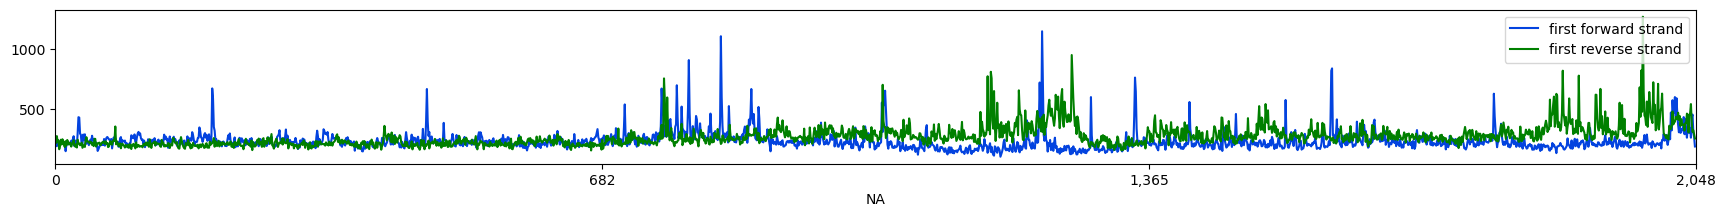

In [79]:
make_tracks(on_cnts).plot()

In [82]:
_sub_tmp = tmp.query("expression  < .1") 
off_cnts = _sub_tmp.df[count_columns].apply(lambda x: SparseIntVector.sum(x).todense(), axis=0)

(<Figure size 2500x200 with 1 Axes>, [<Axes: xlabel='NA'>])

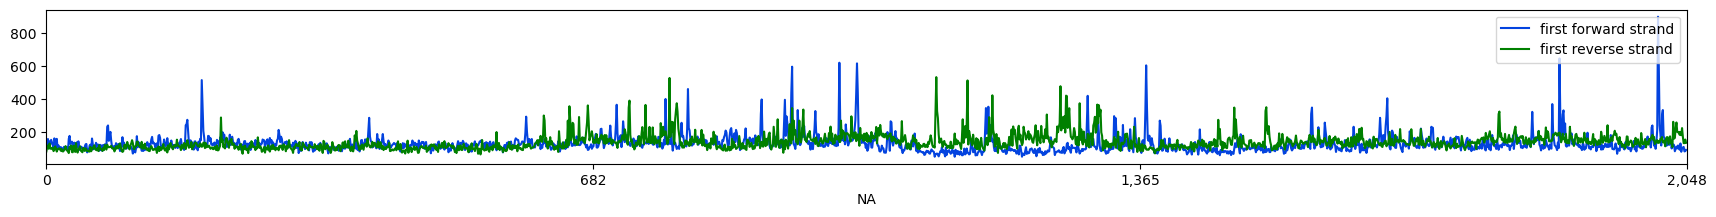

In [83]:
make_tracks(off_cnts).plot()

In [19]:
tmp = srdf.df.join(res)
tmp.head()

,gene_name,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,...,strand_+__fl_40_65__coverage_midpoint,strand_+__fl_120_175__coverage_first,strand_+__fl_120_175__coverage_last,strand_+__fl_120_175__coverage_midpoint,strand_-__fl_40_65__coverage_first,strand_-__fl_40_65__coverage_last,strand_-__fl_40_65__coverage_midpoint,strand_-__fl_120_175__coverage_first,strand_-__fl_120_175__coverage_last,strand_-__fl_120_175__coverage_midpoint
0,ESPN,ENSG00000187017,chr1,+,6423752,6425800,2.216571,1.215192e-176,-2.041034,0.007,...,[],[],[],[],[],[],[],[528 551],[665 723],[597 637]
1,ESPN,ENSG00000187017,chr1,+,6423752,6425800,2.216571,1.215192e-176,-2.041034,0.007,...,[661],[ 55 1591 1982],[ 198 1737],[ 127 1664],[1745],[1785],[1765],[ 429 1620],[ 598 1782],[ 514 1701]
2,ESPN,ENSG00000187017,chr1,+,6423752,6425800,2.216571,1.215192e-176,-2.041034,0.007,...,[ 139 360 625 1720 2013],[ 258 1574 1604 1610 1866],[ 416 1714 1733 1733 2036],[ 337 1644 1669 1672 1951],[1099 1464 1689 1892],[1141 1508 1746 1953],[1120 1486 1718 1923],[ 41 299 1701 1744],[ 1 120 184 431 1843 1865],[ 35 113 365 1772 1805]
3,ESPN,ENSG00000187017,chr1,+,6423752,6425800,2.216571,1.215192e-176,-2.041034,0.007,...,[ 565 651 1817 2001 2028],[ 591 1979],[113 734],[ 43 663],[ 67 1347 1369 1746 1756 1839],[ 122 1397 1409 1796 1812 1882],[ 95 1372 1389 1771 1784 1861],[9],[181],[95]
4,ESPN,ENSG00000187017,chr1,+,6423752,6425800,2.216571,1.215192e-176,-2.041034,0.007,...,[],[1627 2040],[1752],[1690],[ 90 474 1421],[ 146 532 1470],[ 118 503 1446],[ 111 510 1564 1782 1918],[ 231 637 1700 1905],[ 171 574 1632 1844 1996]


In [105]:
%%time
_sub_tmp = tmp.query("avg_log2FC  > 0") 
on_cnts = _sub_tmp[count_columns].apply(lambda x: SparseIntVector.sum(x).todense(), axis=0)

CPU times: user 4.1 s, sys: 151 ms, total: 4.25 s
Wall time: 4.25 s


In [106]:
%%time
on_pred = _sub_tmp[["pred_dist." + c for c in count_columns]].apply(lambda rec: pd.Series({c: rec[c].mean()/rec[c].mean().sum() for c in rec.index})).sum()/len(_sub_tmp)

CPU times: user 4min 1s, sys: 8.4 s, total: 4min 9s
Wall time: 4min 9s


In [107]:
%%time
_sub_tmp = tmp.query("avg_log2FC  < 0") 
off_cnts = _sub_tmp[count_columns].apply(lambda x: SparseIntVector.sum(x).todense())

CPU times: user 3.19 s, sys: 339 ms, total: 3.53 s
Wall time: 3.53 s


In [108]:
off_pred = _sub_tmp[["pred_dist." + c for c in count_columns]].apply(lambda rec: pd.Series({c: rec[c].mean()/rec[c].mean().sum() for c in rec.index})).sum()/len(_sub_tmp)

In [119]:
on_pred['pred_dist.strand_+__fl_40_65__coverage_midpoint']

array([0.00050462, 0.00050501, 0.00050491, ..., 0.00049223, 0.00049288,
       0.00048971])

In [20]:
tmp.query("avg_log2FC  > 0 and label == 0") 

,gene_name,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,...,strand_+__fl_40_65__coverage_midpoint,strand_+__fl_120_175__coverage_first,strand_+__fl_120_175__coverage_last,strand_+__fl_120_175__coverage_midpoint,strand_-__fl_40_65__coverage_first,strand_-__fl_40_65__coverage_last,strand_-__fl_40_65__coverage_midpoint,strand_-__fl_120_175__coverage_first,strand_-__fl_120_175__coverage_last,strand_-__fl_120_175__coverage_midpoint
305,PIK3CD,ENSG00000171608,chr1,+,9650707,9652755,52.590325,0.000000e+00,6.964033,0.207,...,[],[560 620],[720 757],[640 689],[],[18],[],[708],[873],[791]
306,PIK3CD,ENSG00000171608,chr1,+,9650707,9652755,52.590325,0.000000e+00,6.964033,0.207,...,[ 116 1949],[],[],[],[],[],[],[ 120 2022],[280],[200]
307,PIK3CD,ENSG00000171608,chr1,+,9650707,9652755,52.590325,0.000000e+00,6.964033,0.207,...,[386 691 808],[821],[ 55 972],[897],[ 3 50 116 1941 1979 1999 2003 2005 2011 ...,[ 47 105 179 1997 2031 2045],[ 25 78 148 1969 2005 2022 2032 2033 2036 ...,[900],[ 39 1023],[962]
308,PIK3CD,ENSG00000171608,chr1,+,9650707,9652755,52.590325,0.000000e+00,6.964033,0.207,...,[ 544 707 927 1583 1756],[328],[449],[389],[ 874 882 883 1109 1264 1652 1671 1974 1988 ...,[ 18 919 928 939 1158 1305 1704 1710 2028 ...,[ 897 905 911 1134 1285 1678 1691 2001 2017 ...,[ 168 625 690 864 1529 1886],[ 299 768 823 1021 1665 2012],[ 234 697 757 943 1597 1949]
309,PIK3CD,ENSG00000171608,chr1,+,9650707,9652755,52.590325,0.000000e+00,6.964033,0.207,...,[],[1672],[1811],[1742],[2010 2011 2015],[],[2035 2036 2038],[1862 1877],[1988 2024],[1925 1951]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163808,CD40LG,ENSG00000102245,chrX,+,136647134,136649182,6.845717,2.839871e-58,11.122778,0.020,...,[1105],[ 424 812 837 1992 2023],[ 571 952 1008],[498 882 923],[943],[994],[969],[ 451 905 1063 1297],[ 592 1059 1207 1430],[ 522 982 1135 1364]
163809,CD40LG,ENSG00000102245,chrX,+,136647134,136649182,6.845717,2.839871e-58,11.122778,0.020,...,[852],[212 304],[341 477],[277 391],[ 243 998 1978],[ 288 1048 2032],[ 266 1023 2005],[1775],[1926],[1851]
163810,CD40LG,ENSG00000102245,chrX,+,136647134,136649182,6.845717,2.839871e-58,11.122778,0.020,...,[],[1310],[1478],[1394],[],[],[],[ 189 1228 1721],[ 337 1347 1890],[ 263 1288 1806]
163811,CD40LG,ENSG00000102245,chrX,+,136647134,136649182,6.845717,2.839871e-58,11.122778,0.020,...,[1090],[ 90 151 186 1157],[ 246 323 324 1322],[ 168 237 255 1240],[],[],[],[ 187 872 1285 1862 2007],[ 68 353 1014 1430 2027],[ 2 270 943 1358 1945]


(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='NA'>])

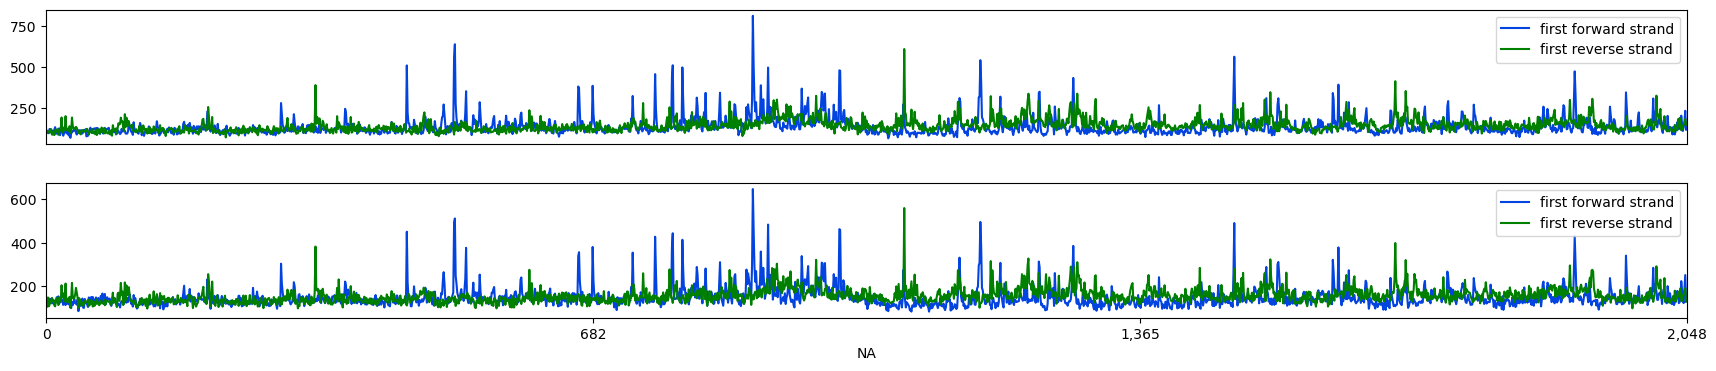

In [42]:
all_tracks = Tracks()
# all_tracks.extend(make_tracks(pd.Series(list((on_cnts.values/on_pred.values)), index=on_cnts.index)))
_sub_tmp = tmp.query("avg_log2FC  > 0 and label == 1") 
on_cnts = _sub_tmp[count_columns].apply(lambda x: SparseIntVector.sum(x).todense(), axis=0)
all_tracks.extend(make_tracks(on_cnts, smooth=False))

_sub_tmp = tmp.query("avg_log2FC  > 0 and label >= 3") 
on_cnts = _sub_tmp[count_columns].apply(lambda x: SparseIntVector.sum(x).todense(), axis=0)
all_tracks.extend(make_tracks(on_cnts, smooth=False))

# all_tracks.extend(make_tracks(pd.Series(dict(on_pred).values(), index=on_cnts.index)))
all_tracks.plot()

In [49]:
on_cnts/len(_sub_tmp)

,strand_+__fl_40_65__coverage_first,strand_+__fl_40_65__coverage_last,strand_+__fl_40_65__coverage_midpoint,strand_+__fl_120_175__coverage_first,strand_+__fl_120_175__coverage_last,strand_+__fl_120_175__coverage_midpoint,strand_-__fl_40_65__coverage_first,strand_-__fl_40_65__coverage_last,strand_-__fl_40_65__coverage_midpoint,strand_-__fl_120_175__coverage_first,strand_-__fl_120_175__coverage_last,strand_-__fl_120_175__coverage_midpoint
0,0.004046,0.004469,0.004750,0.006298,0.007776,0.008374,0.004433,0.004011,0.005067,0.006931,0.006791,0.007494
1,0.003519,0.003870,0.004293,0.006650,0.007565,0.007917,0.004152,0.004222,0.004504,0.007424,0.005594,0.006861
2,0.004011,0.003870,0.005067,0.005911,0.006931,0.007917,0.004820,0.004504,0.004504,0.007741,0.007530,0.008550
3,0.004398,0.004398,0.004750,0.007987,0.007424,0.007706,0.003483,0.004856,0.004328,0.007952,0.006439,0.007283
4,0.004926,0.004539,0.004293,0.007424,0.007002,0.007248,0.003624,0.004750,0.004926,0.006967,0.008761,0.007494
...,...,...,...,...,...,...,...,...,...,...,...,...
2043,0.004785,0.004539,0.005489,0.006157,0.006052,0.006404,0.005594,0.005278,0.004750,0.006615,0.006861,0.006333
2044,0.004222,0.004680,0.005735,0.006791,0.005594,0.006404,0.005524,0.005559,0.005630,0.006474,0.005630,0.006896
2045,0.006404,0.004961,0.004715,0.006685,0.005876,0.007002,0.005981,0.005665,0.005981,0.006228,0.006017,0.007635
2046,0.008726,0.004961,0.006544,0.006439,0.004785,0.006967,0.006509,0.004152,0.004996,0.007741,0.005383,0.006087


(<Figure size 2500x800 with 4 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='NA'>])

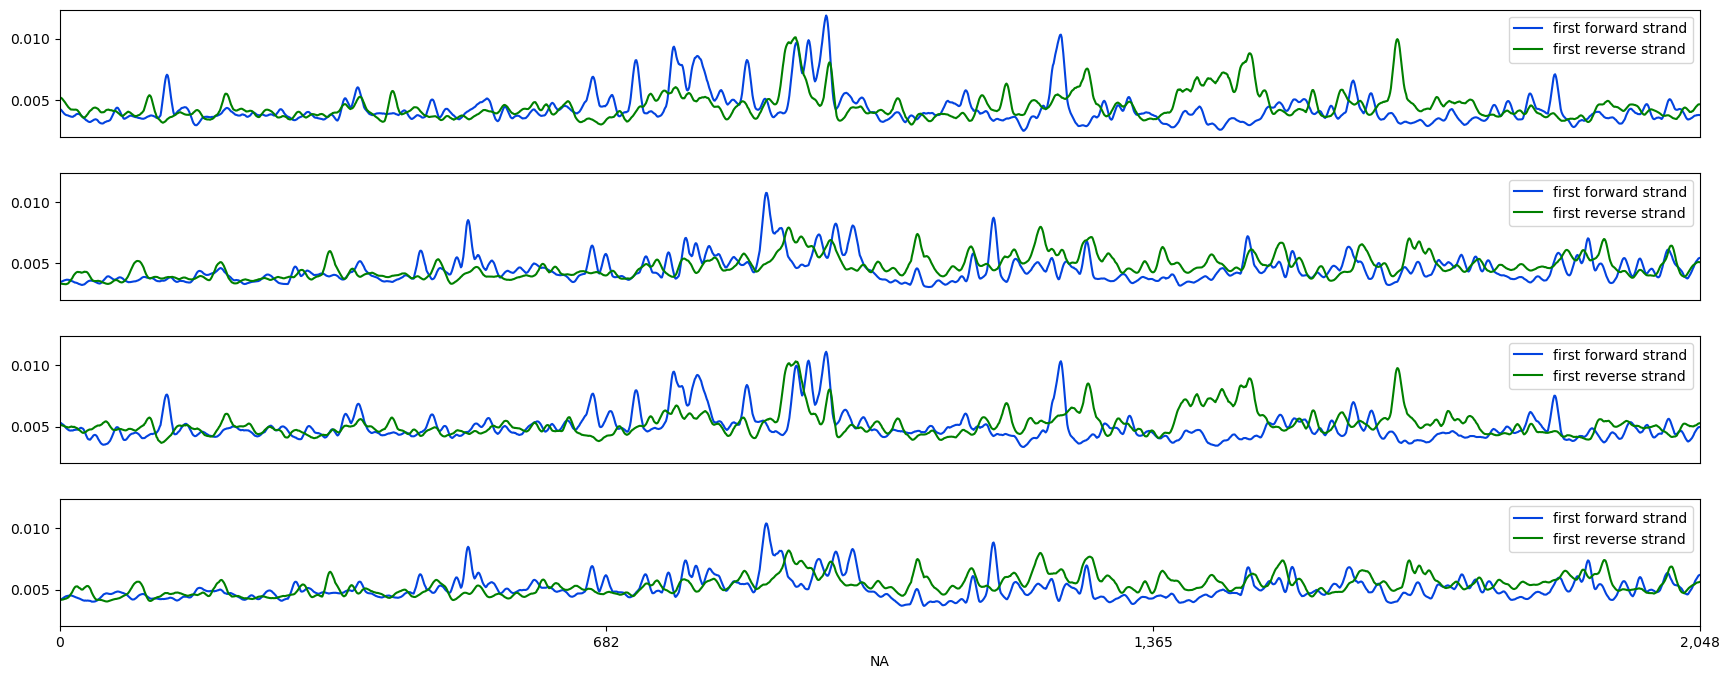

In [51]:
smooth = True
all_tracks = Tracks()
# all_tracks.extend(make_tracks(pd.Series(list((on_cnts.values/on_pred.values)), index=on_cnts.index)))
_sub_tmp = tmp.query("expression < 0.1 and label == 1") 
all_off_cnts = _sub_tmp[count_columns].apply(lambda x: SparseIntVector.sum(x).todense(), axis=0)/len(_sub_tmp)
all_tracks.extend(make_tracks(all_off_cnts, smooth=smooth))

_sub_tmp = tmp.query("avg_log2FC  > 0 and expression > 0.1 and label == 1") 
on_cnts = _sub_tmp[count_columns].apply(lambda x: SparseIntVector.sum(x).todense(), axis=0)/len(_sub_tmp)
all_tracks.extend(make_tracks(on_cnts, smooth=smooth))

_sub_tmp = tmp.query("expression < 0.1 and label >= 3") 
all_off_cnts = _sub_tmp[count_columns].apply(lambda x: SparseIntVector.sum(x).todense(), axis=0)/len(_sub_tmp)
all_tracks.extend(make_tracks(all_off_cnts, smooth=smooth))

_sub_tmp = tmp.query("avg_log2FC  > 0 and expression > 0.1  and label >= 3") 
on_cnts = _sub_tmp[count_columns].apply(lambda x: SparseIntVector.sum(x).todense(), axis=0)/len(_sub_tmp)
all_tracks.extend(make_tracks(on_cnts, smooth=smooth))

# all_tracks.extend(make_tracks(pd.Series(dict(on_pred).values(), index=on_cnts.index)))
all_tracks.plot(sharey=True)

(<Figure size 2500x800 with 4 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='NA'>])

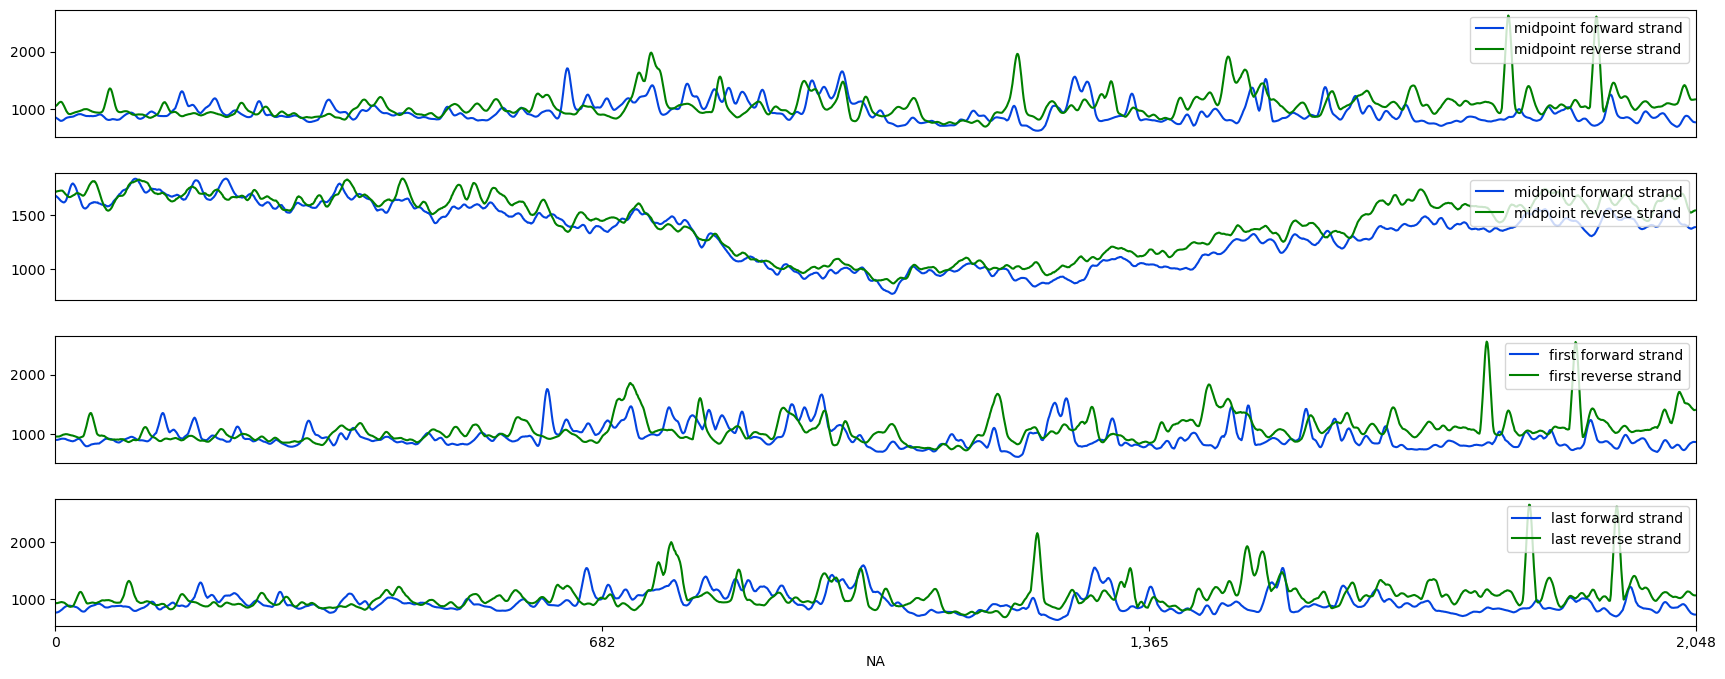

In [128]:
all_tracks = Tracks()
#all_tracks.extend(make_tracks(pd.Series(list((off_cnts.values/off_pred.values)), index=off_cnts.index)))
all_tracks.extend(make_tracks(off_cnts, smooth=True))
#all_tracks.extend(make_tracks(pd.Series(dict(off_pred).values(), index=off_cnts.index)))
all_tracks.plot()

In [27]:
marker_genes

,index,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,direction
0,BEST4,ENSG00000142959,chr1,-,44783585,44788170,0.368135,1.959212e-108,-4.169254,0.006,0.042,5.729519e-104,up_in_colon
1,CD2,ENSG00000116824,chr1,+,116754430,116755021,10.122990,0.000000e+00,7.402749,0.112,0.001,0.000000e+00,down_in_colon
2,FCRLA,ENSG00000132185,chr1,+,161706972,161713452,3.823114,3.256510e-59,8.585422,0.021,0.000,9.523338e-55,down_in_colon
3,NLRP3,ENSG00000162711,chr1,+,247418053,247425792,37.178351,1.154279e-49,9.489926,0.017,0.000,3.375574e-45,down_in_colon
4,TBC1D10C,ENSG00000175463,chr11,+,67403915,67410089,76.448981,1.602647e-260,7.835757,0.090,0.001,4.686782e-256,down_in_colon
5,TESPA1,ENSG00000135426,chr12,-,54948015,54966151,47.577006,3.752280e-236,7.613294,0.082,0.001,1.097317e-231,down_in_colon
6,ARHGAP9,ENSG00000123329,chr12,-,57472264,57477680,68.457228,2.949238e-156,8.289623,0.056,0.001,8.624753e-152,down_in_colon
7,SNX22,ENSG00000157734,chr15,+,64151731,64157481,5.201860,2.109755e-53,7.222411,0.020,0.001,6.169766e-49,down_in_colon
8,ITGAX,ENSG00000140678,chr16,+,31355174,31358455,23.315588,7.693366e-134,7.249486,0.049,0.001,2.249848e-129,down_in_colon
9,CCR7,ENSG00000126353,chr17,-,40553769,40558942,3.997845,4.469245e-219,10.802147,0.075,0.000,1.306986e-214,down_in_colon


In [21]:
marker_genes = build_marker_gene_rdf(hge)
on_gene_ids = marker_genes.query("direction == 'up_in_colon'").gene_id.tolist()
off_gene_ids = marker_genes.query("direction == 'down_in_colon'").gene_id.tolist()
on_in_colon = tmp.query("gene_id in @on_gene_ids")
off_in_colon = tmp.query("gene_id in @off_gene_ids")

(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='NA'>])

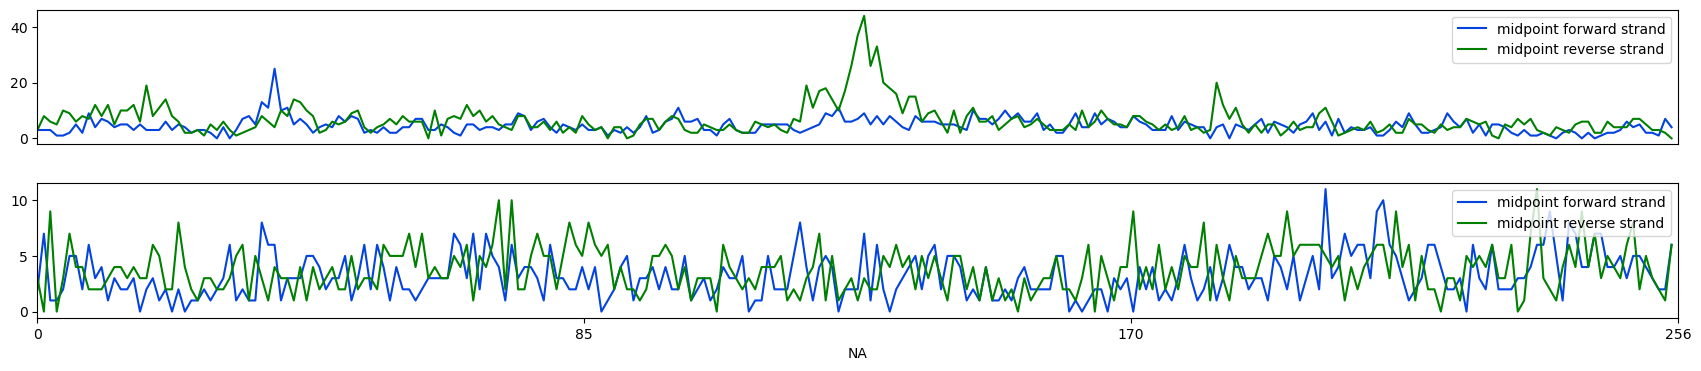

In [22]:
make_tracks(off_in_colon.query("label == 1")[count_columns].sum().apply(lambda x: x.todense().ravel())).plot()

(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='NA'>])

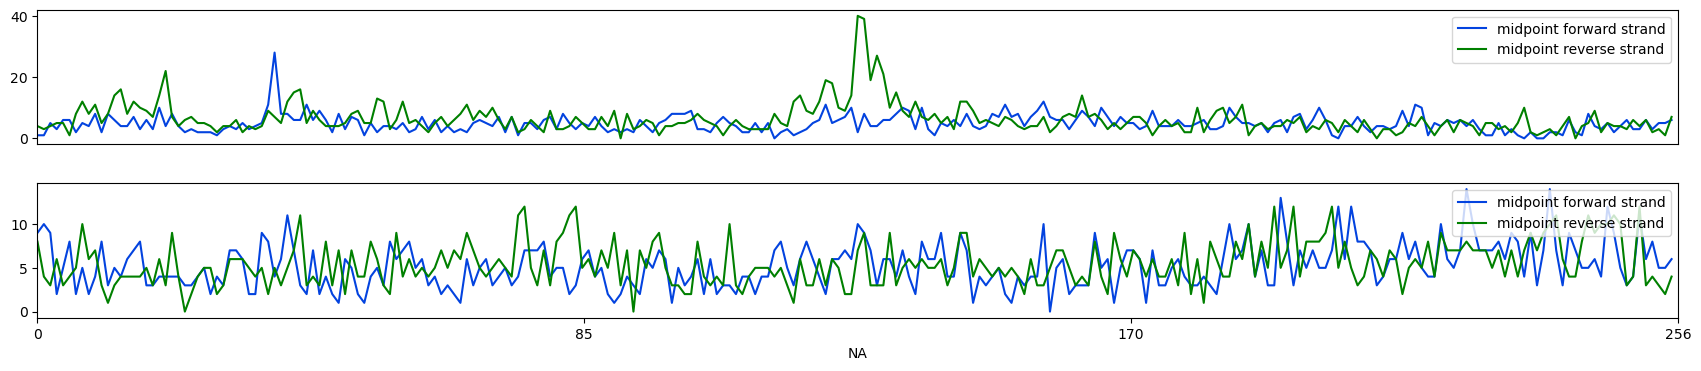

In [23]:
make_tracks(off_in_colon.query("label >= 3")[count_columns].sum().apply(lambda x: x.todense().ravel())).plot()

(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='NA'>])

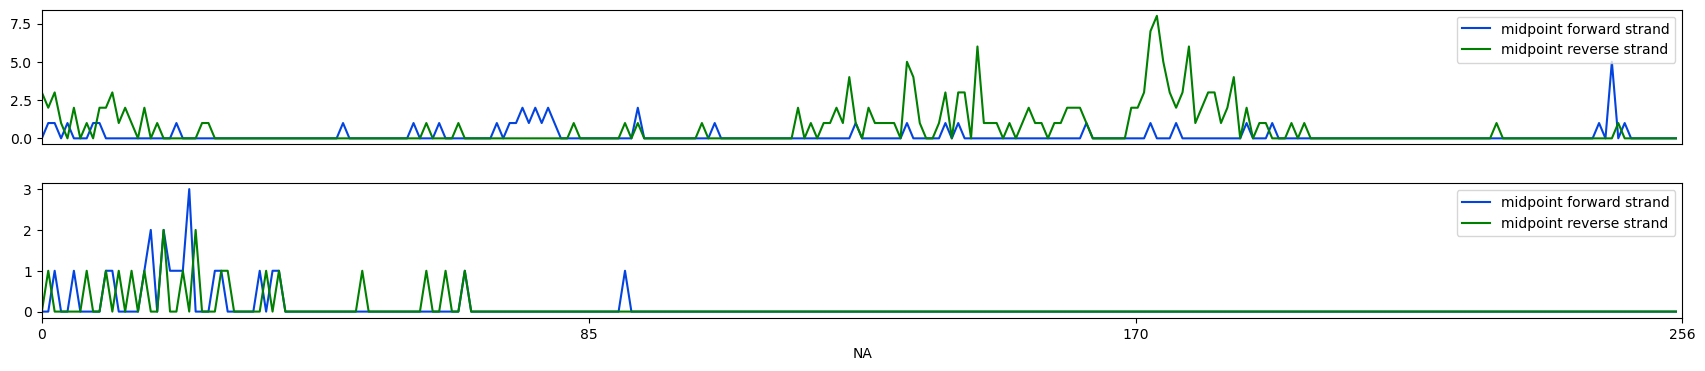

In [24]:
make_tracks(on_in_colon.query("label == 1")[count_columns].sum().apply(lambda x: x.todense().ravel())).plot()

(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='NA'>])

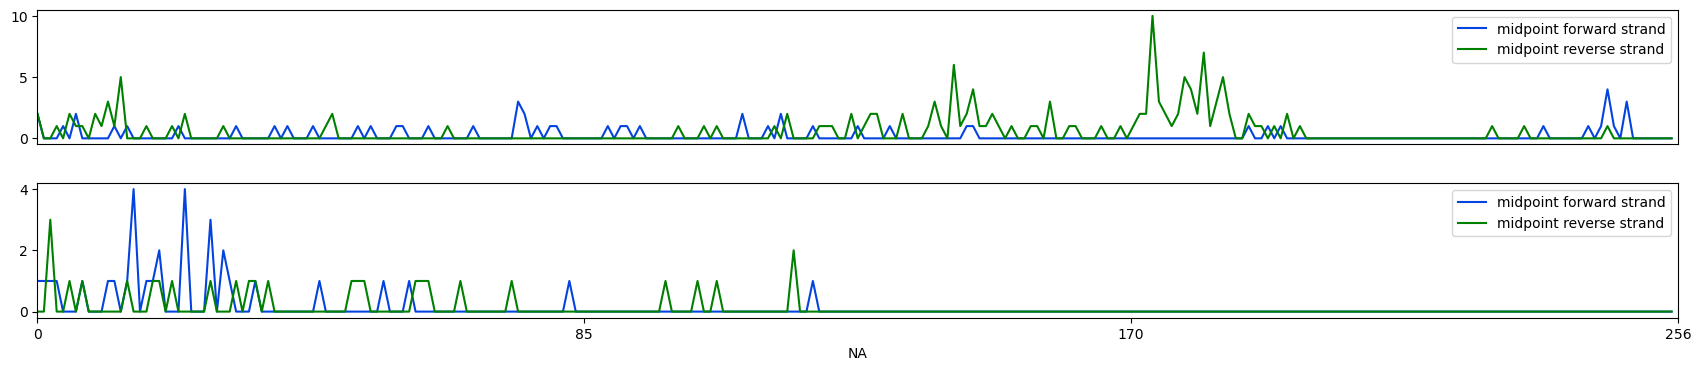

In [25]:
make_tracks(on_in_colon.query("label >= 3")[count_columns].sum().apply(lambda x: x.todense().ravel())).plot()

 # Corrected

In [41]:
def build_normalized_counts(record):
    fa = record.fragment_array.drop_duplicate_fragments()
    pseudo_count = 1./record.fragment_array.length

    # subset_by_fragment_strand('+')
    fwd_cov = fa.subset_fragment_lengths(40, 60).first_covered_base_counts
    fwd_means = record.fwd_start_counts_dist.mean()
    fwd_cov_pred = fwd_cov.sum()*(fwd_means/fwd_means.sum())

    # .subset_by_fragment_strand('-')
    bkwd_cov = fa.subset_fragment_lengths(40, 60).last_covered_base_counts
    bkwd_means = record.bkwd_stop_counts_dist.mean()
    bkwd_cov_pred = bkwd_cov.sum()*(bkwd_means/bkwd_means.sum())

    fwd_bkwd_ratio = fwd_means.sum()/bkwd_means.sum()
    
    fwd_cov_norm = fwd_cov/(fwd_cov_pred.clip(pseudo_count, None))
    fwd_cov_norm *= fwd_cov.sum()/(fwd_cov_norm.sum()+1e-6)

    bkwd_cov_norm = bkwd_cov/(bkwd_cov_pred.clip(pseudo_count, None))
    bkwd_cov_norm *= bkwd_cov.sum()/(bkwd_cov_norm.sum()+1e-6)

    return pd.Series(dict(fwd_cov=fwd_cov, fwd_cov_pred=fwd_cov_pred, fwd_cov_norm=fwd_cov_norm, bkwd_cov=bkwd_cov, bkwd_cov_pred=bkwd_cov_pred, bkwd_cov_norm=bkwd_cov_norm))

def build_aggregated_coverage(srdf):
    tmp = srdf.df.apply(build_counts, axis=1)
    df = pd.DataFrame(list(tmp.sum())).T
    df.columns = tmp.columns
    return df

In [ ]:
counts = srdf.df.progress_apply(build_counts, axis=1)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 383645/383690 [05:45<00:00, 1125.77it/s]

(<Figure size 2500x800 with 5 Axes>,
 [<Axes: title={'center': ' 8205764 frags'}>, <Axes: >, <Axes: xlabel='NA'>])

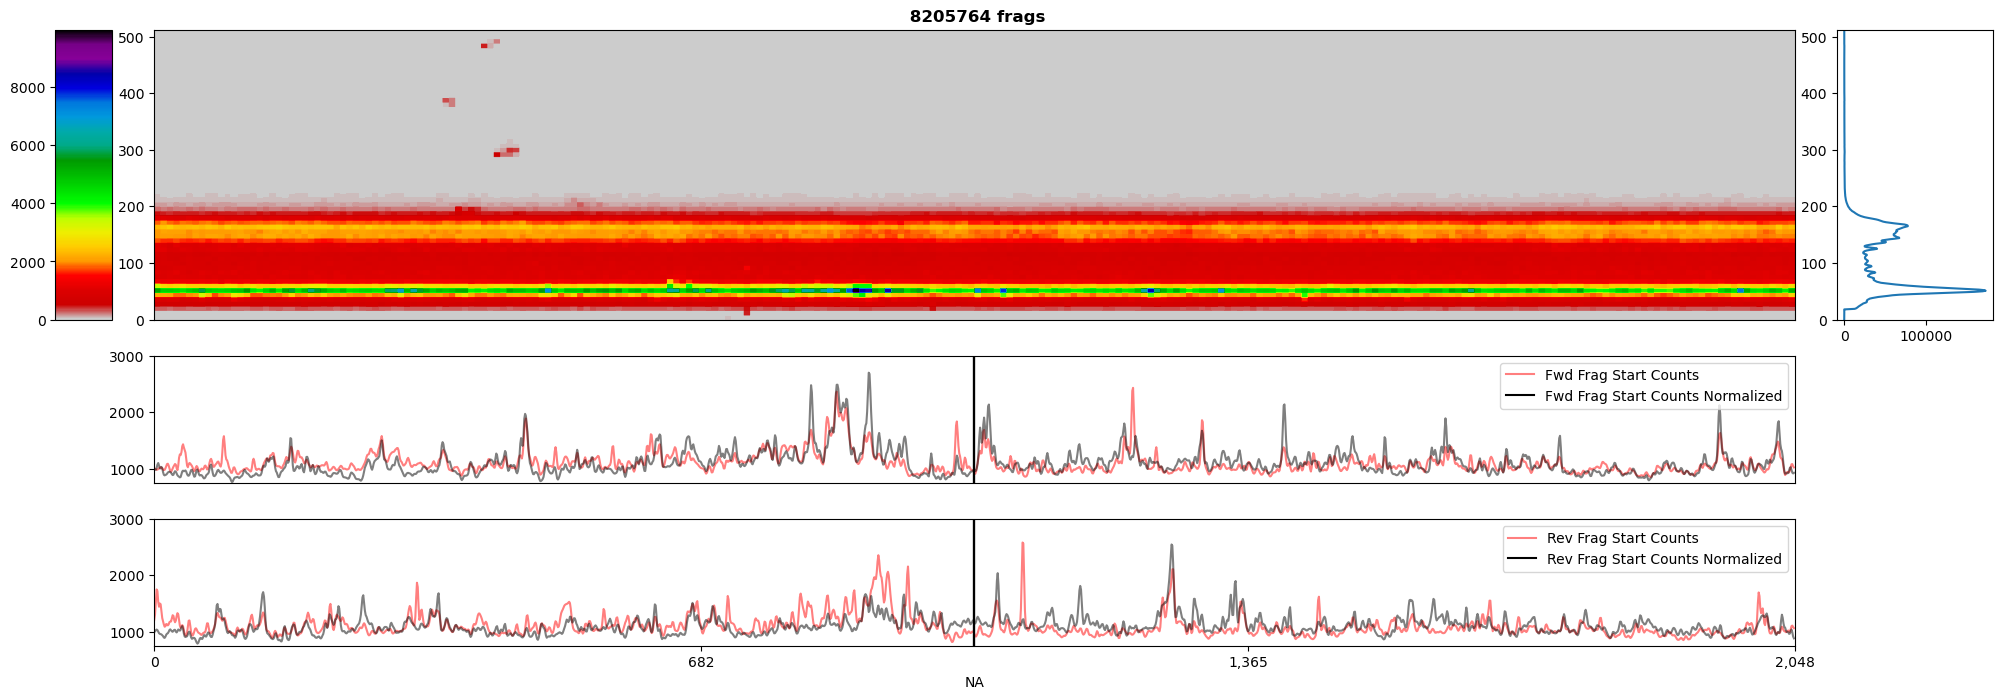

In [34]:
from fragmentomics_tools.plot.tracks import CoverageTrack, VLine, Tracks, VplotTrack, StrandSplitCoverageTrack, VectorTrack


sm_win_len = 5
ylim = (750, 3000)
tracks = Tracks()
tracks.append(VplotTrack(fa, sum_pool_by=8))
tracks.append(
    VectorTrack(tmp.fwd_cov.sum(), color='red', smooth=True, smooth_window_len=sm_win_len, alpha=0.5, ylim=ylim, name='Fwd Frag Start Counts', vlines=[VLine(x=1024)]) \
    + VectorTrack(tmp.fwd_cov_norm.sum(), color='black', smooth=True, smooth_window_len=sm_win_len, alpha=0.5, ylim=ylim, name='Fwd Frag Start Counts Normalized')
)
tracks.append(
    VectorTrack(tmp.bkwd_cov.sum(), color='red', smooth=True, smooth_window_len=sm_win_len, alpha=0.5, ylim=ylim, name='Rev Frag Start Counts', vlines=[VLine(x=1024)]) \
    + VectorTrack(tmp.bkwd_cov_norm.sum(), color='black', smooth=True, smooth_window_len=sm_win_len, alpha=0.5, ylim=ylim, name='Rev Frag Start Counts Normalized')
)
tracks.plot()

(<Figure size 2500x1400 with 7 Axes>,
 [<Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: xlabel='NA'>])

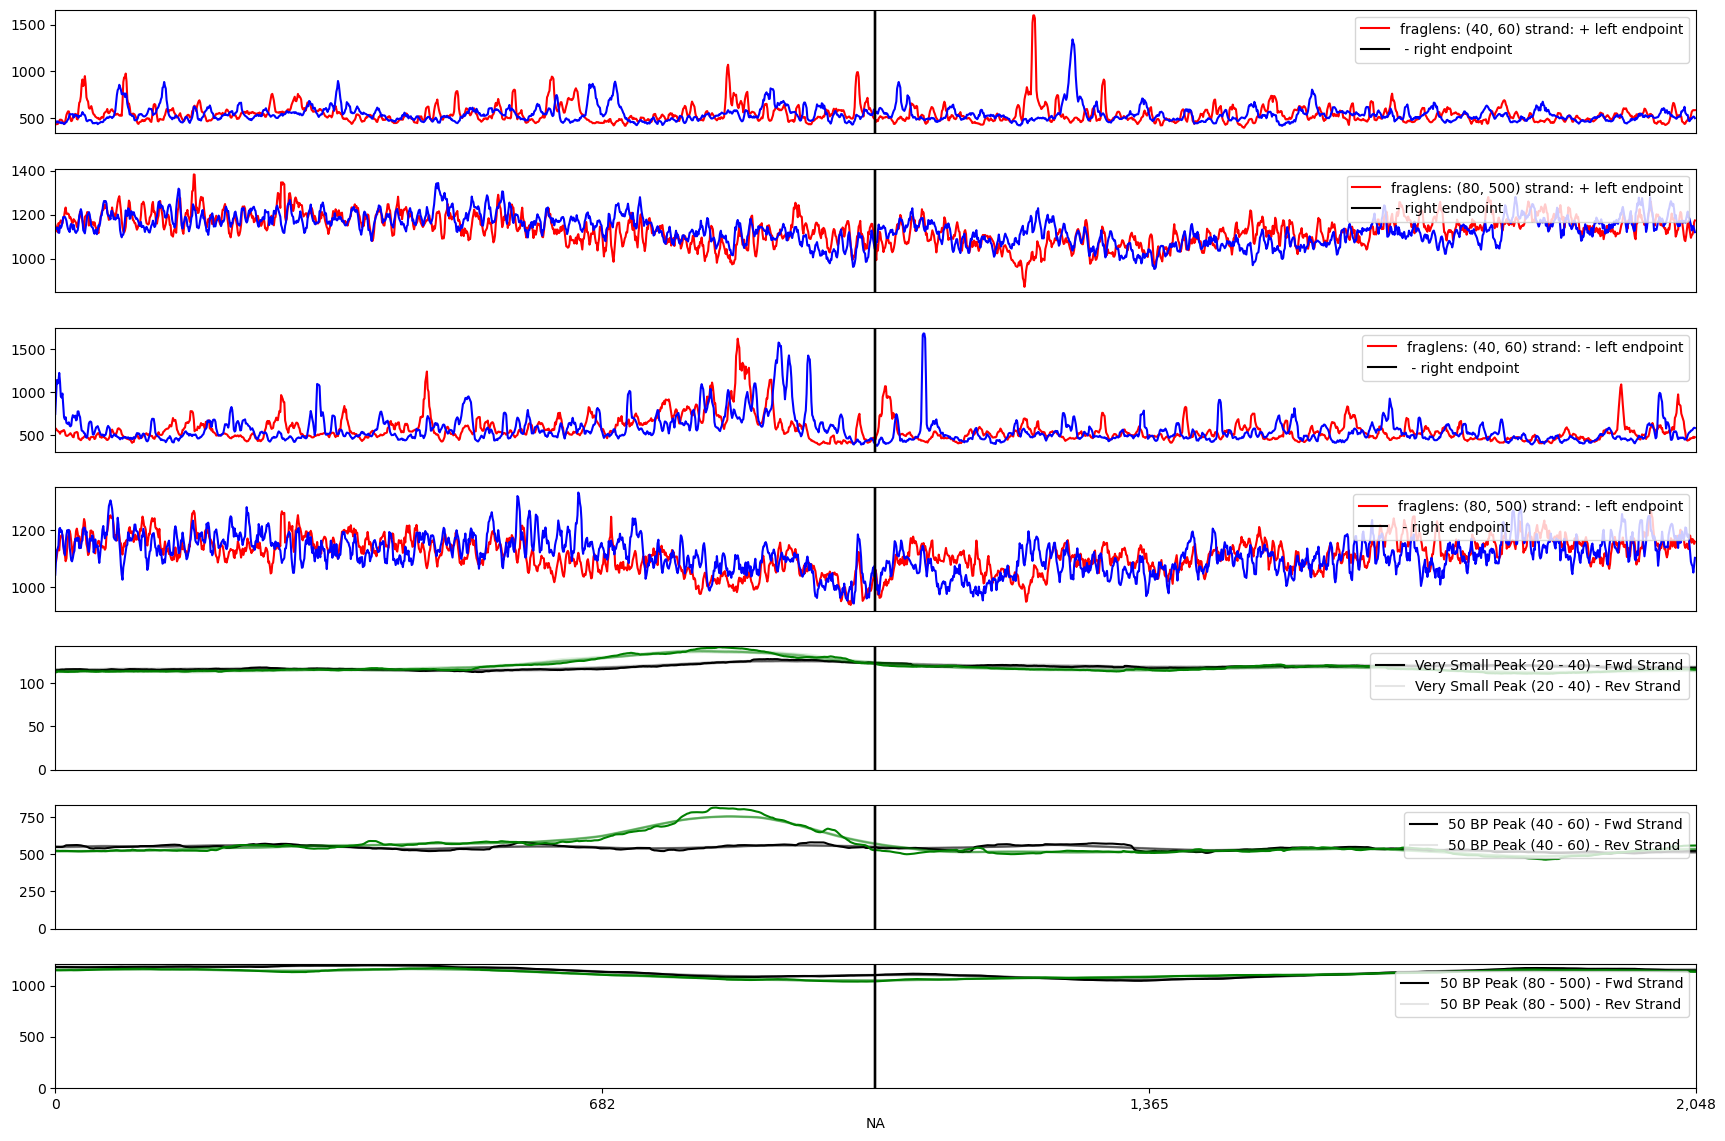

In [32]:
make_tracks(fa).plot()

(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='NA'>])

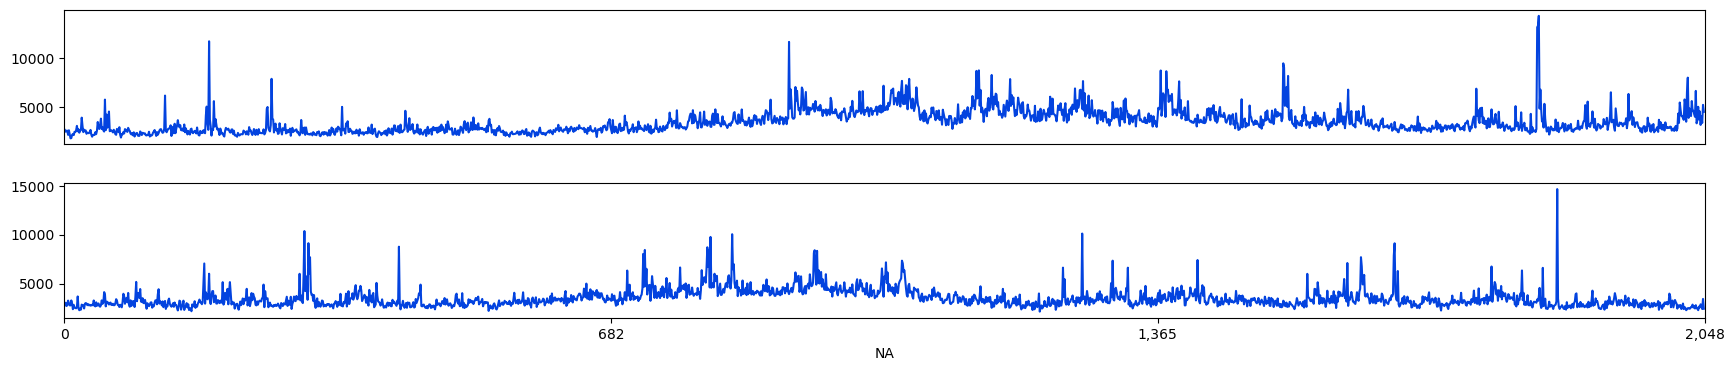

In [71]:
tracks = Tracks()
tracks.append(VectorTrack(tmp.fwd_cov_norm.sum()))
tracks.append(VectorTrack(tmp.bkwd_cov_norm.sum()))
tracks.plot()

(<Figure size 2500x1400 with 7 Axes>,
 [<Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: xlabel='NA'>])

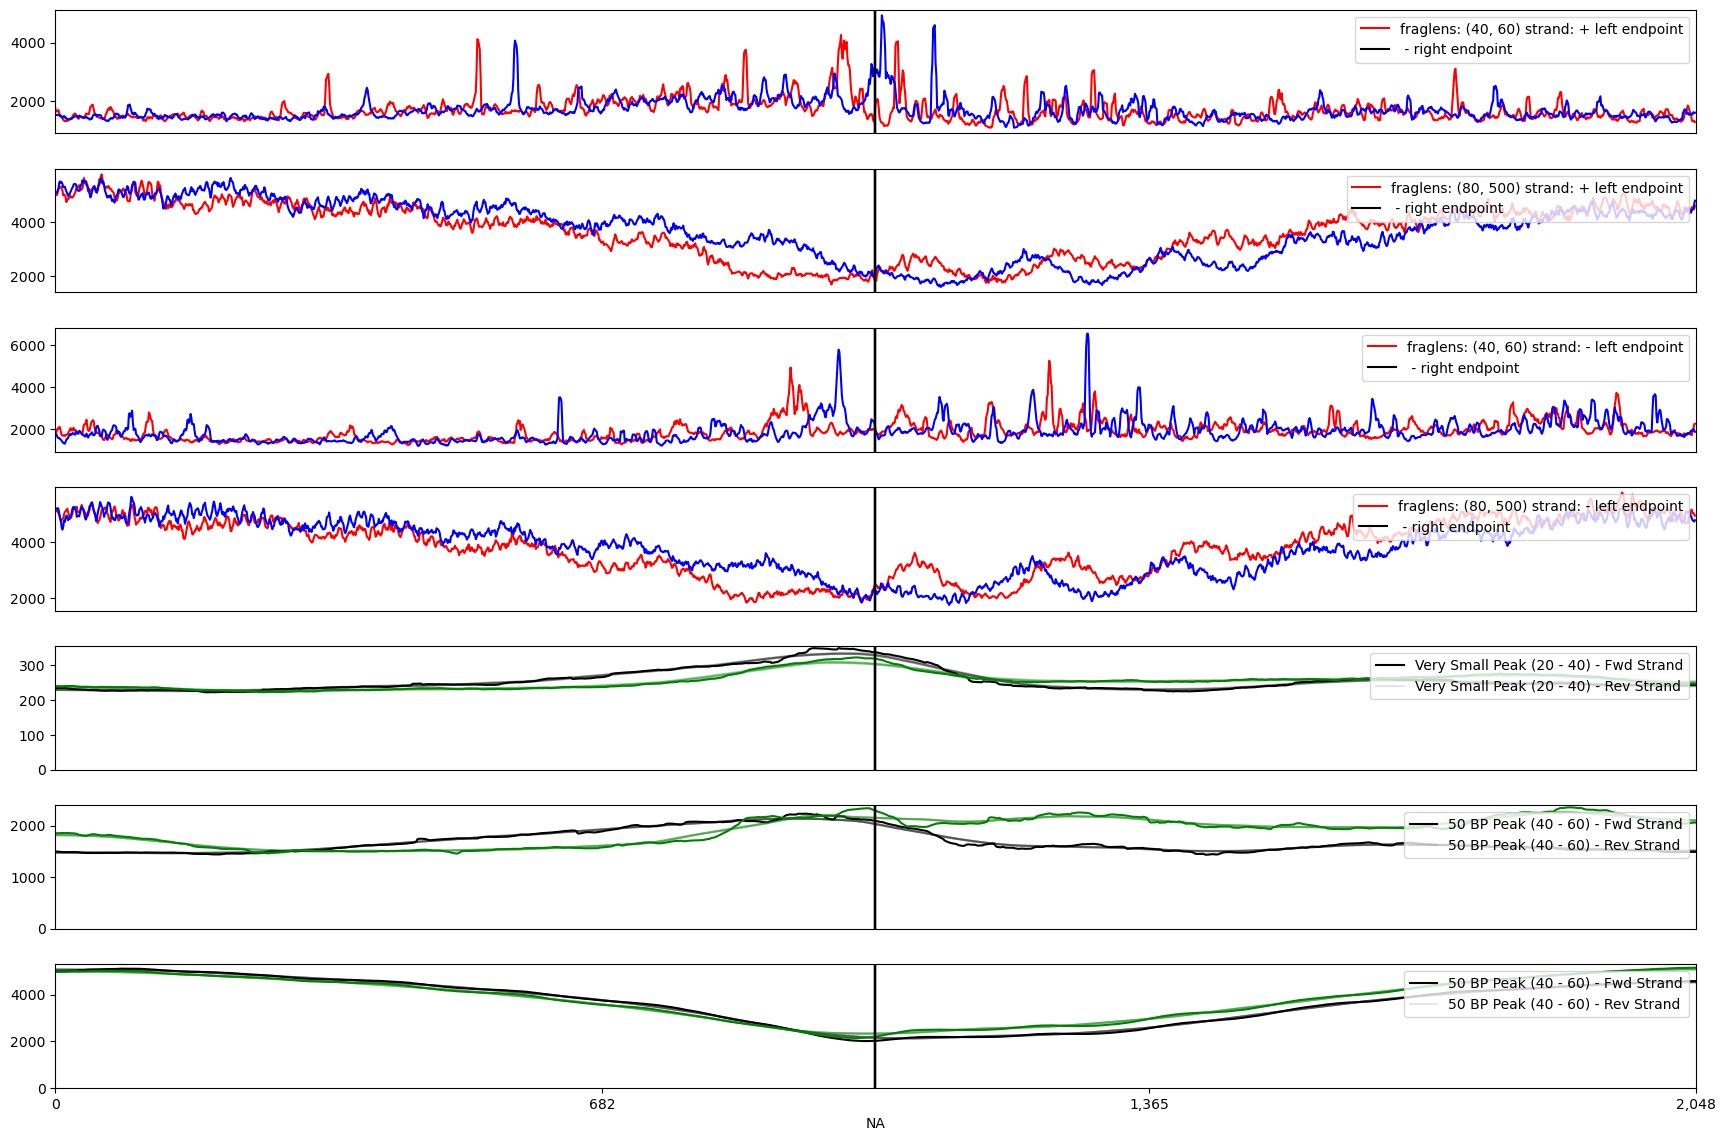

In [33]:
make_tracks(fa).plot()

In [17]:
def get_labeled_tss_s():
    filtered_tss_s = tss_s.query("num_tss_in_gene == 1").merge_gene_expression(gene_expression).copy()

    blood_labels = filtered_tss_s.set_binary_label_by_thresholds(
        blood_cell_eids[6],
        on_threshold=25,
        off_threshold=0.01,
        drop_unlabeled_records=False,
    )['label'].rename('blood_label')

    gi_labels = filtered_tss_s.set_binary_label_by_thresholds(
        gi_cell_eids[:1],
        on_threshold=25,
        off_threshold=0.01,
        drop_unlabeled_records=False,
    )['label'].rename('gi_label')


    filtered_tss_s.loc[:, 'cell_type'] = None
    filtered_tss_s.loc[(gi_labels == 1) & (blood_labels == 1), 'cell_type'] = 'all'
    filtered_tss_s.loc[(gi_labels == 1) & (blood_labels == 0), 'cell_type'] = 'gi'
    filtered_tss_s.loc[(gi_labels == 0) & (blood_labels == 1), 'cell_type'] = 'blood'
    filtered_tss_s.loc[(gi_labels == 0) & (blood_labels == 0), 'cell_type'] = 'none'

    filtered_tss_s['gene_id'] = filtered_tss_s.id.str.extract('(ENSG\d+)\..+')

    filtered_tss_s = filtered_tss_s.dropna().reset_index(drop=True)
    
    return filtered_tss_s

In [531]:
filtered_tss_s = get_labeled_tss_s()
filtered_tss_s.cell_type.value_counts()

[autoreload of ravel.fragment_array failed: Traceback (most recent call last):
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 257, in check
    superreload(m, reload, self.old_objects)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 480, in superreload
    update_generic(old_obj, new_obj)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 377, in update_generic
    update(a, b)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 329, in update_class
    if update_generic(old_obj, new_obj):
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 377, in update_generic
    update(a, b)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", li

none     1850
all       663
gi         61
blood       8
Name: cell_type, dtype: int64

In [19]:
filtered_tss_s, counts, fragment_stats = make_counts_and_region_stats(filtered_tss_s, sample_ids_to_samples)

  6%|██████████████████                                                                                                                                                                                                                                                                                                                    | 1/18 [00:06<01:42,  6.05s/it]


KeyboardInterrupt: 

In [ ]:
filtered_tss_s.cell_type.value_counts()

In [ ]:
# filtered_tss_s.query("cell_type == 'all'")
fa, fas = fa_from_rdf(filtered_tss_s.query("cell_type == 'all'"), FragmentsH5(sample_ids_to_samples['RD-56167']), region_size=4096, downsample_size=None, fl_normalize=False)

In [ ]:
fa = fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == 'all'"), region_size=4096*32, fl_normalize=True, max_num_samples=12)

In [ ]:
make_tracks(fa, True, True, True).plot(title="Active TSS's over ALL IBD Samples")

In [ ]:
none_fa = fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == 'none'"), region_size=4096*32, fl_normalize=True, max_num_samples=12)

In [ ]:
make_tracks(none_fa, True, True, True).plot(title="In-Active TSS's over ALL IBD Samples")

In [ ]:
fa = fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == 'blood'"), region_size=4096, fl_normalize=True, max_num_samples=12)

In [ ]:
make_tracks(fa, True, True, True).plot(title="Blood TSS's over ALL IBD Samples")

In [ ]:
list(filtered_tss_s.cell_type.unique())

In [ ]:
for cell_type in filtered_tss_s.cell_type.unique():
    make_tracks(fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == @cell_type").sample(90), region_size=4096, fl_normalize=False, max_num_samples=12), extra_tracks=True).plot(title=f'TSS Expressed in {cell_type.upper()} across All Samples')

# Simulations

In [ ]:
RegionFragmentArray.from_fragments_h5("/scratch/test_samples/SEQRUN48_LIBRARY574.fragments.h5", Region.from_region_str("chr1:91419-91436").resize(1024))

In [ ]:
neg_density = fm_from_regions_mask(only_neural_mask).sum_pooled(1).dense_array.clip(1e-5)
neg_density = neg_density/neg_density.sum()

In [ ]:
pos_density = fm_from_regions_mask(only_blood_mask).sum_pooled(1).dense_array.clip(1e-5)
pos_density = pos_density/pos_density.sum()

In [ ]:
neg_density.ravel()

In [ ]:
from numpy.random import multinomial as sample_multinomial
from scipy.stats import multinomial as multinomal_density
def sample(p, n):
    x = sample_multinomial(n, p.ravel())
    x.resize(p.shape)
    return x

In [ ]:
n = 10000
disease_frac = 0.5
true = disease_frac*pos_density + (1-disease_frac)*neg_density
obs = sample(true, n)

multinomal_density.logpmf(obs.ravel(), obs.sum(), true.ravel())

In [ ]:
true.shape, obs.shape

In [ ]:
import numpy
numpy.random.rand(100)

# Gene Analysis

In [20]:
# use the gencode basic gtf to find all exonic regions 
# filter by: gene_type "protein_coding"
# find all genes by 
# merge all exons by gene
# take the gene end to be the first poly(A) tail (or the nearest end of the transcript)
# save into a region data frame, and attach fragment matrices
# build the coverage plots banded by fragment size
# stich these together, making sure that the fragment midpoint overlaps the exon
# make some plots!!!

In [416]:
%%time
gencode_df = pd.read_table(
    "/scratch/nboley/gencode/gencode.v39.basic.annotation.protein_coding.gff3",
    usecols=[0, 2, 3, 4, 6, 8],
    names=["contig", "element", "start", "stop", "strand", "meta"],
).query("contig not in ['chrM', 'chrY'] and element in ['transcript', 'exon', 'three_prime_UTR', 'five_prime_UTR']")
gencode_df['gene_id'] = gencode_df.meta.str.extract(';gene_id=(ENSG?\d+)\.\d+;')
gencode_df = gencode_df.drop(columns=['meta'])
gencode_df = gencode_df.drop_duplicates()
gencode_df = gencode_df.sort_values(["contig", "start"])

CPU times: user 8.86 s, sys: 376 ms, total: 9.23 s
Wall time: 9.24 s


In [417]:
gencode_df.element.value_counts()

exon               289650
five_prime_UTR      75701
transcript          58797
three_prime_UTR     54810
Name: element, dtype: int64

In [426]:
gencode_df.query("strand == '-'").head()

,contig,element,start,stop,strand,gene_id
13,chr1,transcript,450740,451678,-,ENSG00000284733
14,chr1,exon,450740,451678,-,ENSG00000284733
19,chr1,transcript,685716,686654,-,ENSG00000284662
20,chr1,exon,685716,686654,-,ENSG00000284662
125,chr1,transcript,944203,959256,-,ENSG00000188976


In [418]:
filtered_tss_s = get_labeled_tss_s() # [['gene_id', 'cell_type']]
filtered_tss_s

,contig,start,stop,id,score,strand,ens_id,num_tss_in_gene,pk_tpm,peakiness,...,E118,E119,E120,E122,E123,E127,E128,label,cell_type,gene_id
0,chr20,50958528,50958529,ENSG00000000419.12_pk1,1000,-,ENSG00000000419,1,121.79,0.7301,...,62.811,42.386,54.869,16.652,73.719,56.578,56.371,1,all,ENSG00000000419
1,chr1,196652051,196652052,ENSG00000000971.15_pk1,1000,+,ENSG00000000971,1,145.20,0.8823,...,0.007,0.419,39.724,8.464,41.504,1.348,32.725,1,all,ENSG00000000971
2,chr17,38870053,38870054,ENSG00000002834.17_pk1,1000,+,ENSG00000002834,1,317.87,0.8141,...,70.159,85.268,128.565,144.330,49.802,86.640,143.304,1,all,ENSG00000002834
3,chr7,127588432,127588433,ENSG00000004059.10_pk1,1000,+,ENSG00000004059,1,39.73,0.5661,...,81.860,198.680,89.048,230.688,108.866,124.927,65.374,1,all,ENSG00000004059
4,chr16,23596298,23596299,ENSG00000004779.9_pk1,1000,-,ENSG00000004779,1,88.24,0.4748,...,136.382,62.265,67.906,121.874,175.205,79.225,49.491,1,all,ENSG00000004779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2577,chr18,73473,73474,ENSG00000282965.1_pk1,1000,-,ENSG00000282965,1,4.53,0.3139,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000282965
2578,chr7,150405799,150405800,ENSG00000283013.1_pk1,1000,+,ENSG00000283013,1,1.53,0.1900,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000283013
2579,chr4,119454625,119454626,ENSG00000283050.1_pk1,1000,-,ENSG00000283050,1,20.06,0.3425,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000283050
2580,chr20,22685459,22685460,ENSG00000283072.1_pk1,1000,+,ENSG00000283072,1,2.86,0.5813,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000283072


In [504]:
p_gene_starts_and_stops = filtered_tss_s.query("strand == '+'").set_index('gene_id')[['start', 'cell_type']].rename(columns={'start': 'tss'}).join(gencode_df.set_index('gene_id'), how='inner').query("element == 'transcript'")[['contig', 'tss', 'stop', 'strand', 'cell_type']].groupby(['gene_id']).min().rename(columns={'tss': 'start'})
p_gene_starts_and_stops['stop'] = p_gene_starts_and_stops['start'] + 1024*60
p_gene_starts_and_stops['start'] = p_gene_starts_and_stops['start'] - 4096


m_gene_starts_and_stops = filtered_tss_s.query("strand == '-'").set_index('gene_id')[['start', 'cell_type']].rename(columns={'start': 'tss'}).join(gencode_df.set_index('gene_id'), how='inner').query("element == 'transcript'")[['contig', 'tss', 'start', 'strand', 'cell_type']].groupby(['gene_id']).max().rename(columns={'tss': 'stop'})
m_gene_starts_and_stops['start'] = m_gene_starts_and_stops['stop'] - 1024*60
m_gene_starts_and_stops['stop'] = m_gene_starts_and_stops['stop'] + 4096


In [505]:
gene_starts_and_stops = pd.concat([p_gene_starts_and_stops, m_gene_starts_and_stops]).sort_values(['start', 'stop']).query('start > 0')
gene_starts_and_stops.cell_type.value_counts()

all      663
none     498
gi        61
blood      7
Name: cell_type, dtype: int64

In [506]:
#gene_starts = gencode_df.query("strand == '+' and element == 'five_prime_UTR'")[['gene_id', 'start']].groupby('gene_id').start.max() 
#gene_stops = gencode_df.query("strand == '+' and element == 'three_prime_UTR'")[['gene_id', 'stop']].groupby('gene_id').stop.min()
#gene_starts_and_stops = pd.DataFrame(gene_starts).join(gene_stops, how='inner')
#gene_starts_and_stops = gene_starts_and_stops.join(filtered_tss_s.set_index("gene_id"), how='inner')

In [507]:
?Region

Init signature:
Region(
    chrom: str,
    start: int = None,
    stop: int = None,
    strand: Optional[str] = None,
    ref: str = 'hg38',
    data: dict = None,
) -> None
Docstring:      Region(chrom: str, start: int = None, stop: int = None, strand: Optional[str] = None, ref: str = 'hg38', data: dict = None)
File:           ~/src/Ravel/fbio/region.py
Type:           type
Subclasses:     


In [508]:
%%time

def hstack_fas(fas):
    rv = fas[0]
    for fa in fas[1:]:
        rv = rv.hstack(fa)
    return rv

def get_fas(regions):
    # deal with positive strand
    # exon_grouper = gencode_df.query("strand == '+' and element == 'exon'")[['gene_id', 'contig', 'strand', 'start', 'stop']].groupby('gene_id')
    fas = {}
    for record in tqdm.tqdm(regions.itertuples(), total=regions.shape[0]):
        # gene_exons_df = RegionDataFrame(exon_grouper.get_group(record.Index).query("start >= @record.start and stop <= @record.stop"), ref='hg38')
        # if gene_exons_df.shape[0] == 0: continue
        inner_fas = []
        for frag_h5 in frag_h5s:
            inner_fas.append(RegionFragmentArray.from_fragments_h5(frag_h5, Region(record.contig, record.start, record.stop, record.strand), include_fragment_strand=True, flip_data_to_match_region_strand=True)) 
            # hstack_fas([RegionFragmentArray.from_fragments_h5(frag_h5, r, include_fragment_strand=True, flip_data_to_match_region_strand=True) for r in gene_exons_df.iter_regions()]))
        if len(inner_fas) > 0:
            fas[record.Index] = merge_fragment_arrays(inner_fas)

    return fas

CPU times: user 14 µs, sys: 2 µs, total: 16 µs
Wall time: 17.9 µs


In [509]:
fas = get_fas(gene_starts_and_stops)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1229/1229 [01:39<00:00, 12.40it/s]


In [510]:
df = gene_starts_and_stops.join(pd.Series(fas).rename('fa')).dropna()
df['fa_length'] = [fa.length for fa in df.fa.tolist()]
df['n_fragments'] = [fa.n_fragments for fa in df.fa.tolist()]

In [511]:
df['fa_length'].value_counts()

65536    1229
Name: fa_length, dtype: int64

<AxesSubplot:>

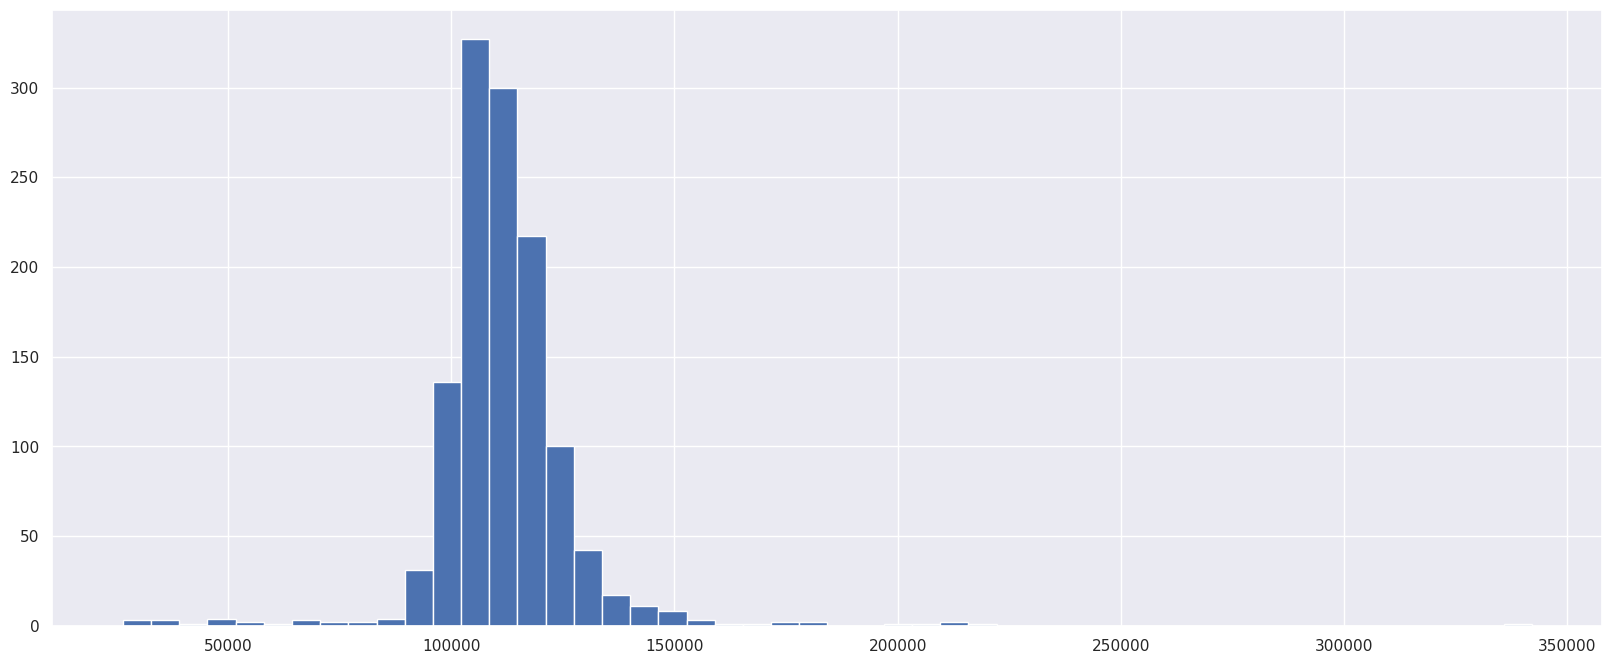

In [512]:
df['n_fragments'].hist(bins=50)

In [513]:
df

,contig,start,stop,strand,cell_type,fa,fa_length,n_fragments
gene_id,,,,,,,,
ENSG00000272602,chr4,49230,114766,+,none,"RegionFragmentArray(n_frags=142597, region=chr...",65536,142597
ENSG00000185627,chr11,232875,298411,+,all,"RegionFragmentArray(n_frags=125994, region=chr...",65536,125994
ENSG00000185885,chr11,309433,374969,+,all,"RegionFragmentArray(n_frags=146204, region=chr...",65536,146204
ENSG00000130731,chr16,574877,640413,-,all,"RegionFragmentArray(n_frags=113901, region=chr...",65536,113901
ENSG00000169020,chr4,612842,678378,-,all,"RegionFragmentArray(n_frags=211291, region=chr...",65536,211291
...,...,...,...,...,...,...,...,...
ENSG00000135902,chr2,232522104,232587640,+,none,"RegionFragmentArray(n_frags=118226, region=chr...",65536,118226
ENSG00000244474,chr2,233714693,233780229,+,gi,"RegionFragmentArray(n_frags=115849, region=chr...",65536,115849
ENSG00000182177,chr2,236202964,236268500,-,none,"RegionFragmentArray(n_frags=122924, region=chr...",65536,122924


In [514]:
import copy
from dataclasses import dataclass, field, replace
from fbio.plot.tracks import CoverageTrack, VLine, Tracks, VplotTrack

# frag_h5 = FragmentsH5("/scratch/karius/finished.fragments.h5") # "/scratch/test_samples/SEQRUN48_LIBRARY577.fragments.h5")
patient_groups = ['Patient Group  1', 'Patient Group  2']
patient_groups = metadata.Cluster.unique().tolist()

severities = ('Remission', 'Mild', 'Moderate', 'Severe')

from fbio.plot.tracks import CoverageTrack, VLine, Tracks, VplotTrack

@dataclass
class CoverageDifferenceTrack(CoverageTrack):
    def _build_coverage(self, *args, **kwargs):
        c1 = copy.deepcopy(self.data).subset_fragment_lengths(self.fraction[0], self.fraction[1]).subset_by_fragment_strand('+').get_midpoint_coverage_array() 
        c2 = copy.deepcopy(self.data).subset_fragment_lengths(self.fraction[0], self.fraction[1]).subset_by_fragment_strand('-').get_midpoint_coverage_array() 
        return c2 - c1

    def _plot(self, ax): 
        super()._plot(ax)
        ax.axhline(0)

def StrandSplitCoverageTrack(fa, *args, **kwargs):
    p1 = CoverageTrack(fa.subset_by_fragment_strand('+'), *args, color='black', **kwargs)
    p1.name = p1.name + ' - Fwd Strand'
    p2 = CoverageTrack(fa.subset_by_fragment_strand('-'), *args, color='green', **kwargs)
    p2.name = p2.name + ' - Rev Strand'
    return p1 + p2

def make_single_strand_tss_tracks(fa, include_vplot=False):
    region_size = fa.shape[1]

    region_size//2+145
    first_nuc=132
    offset=175
    tracks = Tracks()
    if include_vplot:
        tracks.append(VplotTrack(fa, fa.plot_region, sum_pool_by=2))

    for fraction, sm_win in [((40, 60), 300), ((60, 100), 700), ((110, 500), 1500)]:
        for TrackCls in (StrandSplitCoverageTrack, CoverageDifferenceTrack):
            tracks.append(TrackCls(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=0, fraction=fraction, smooth_window=sm_win, ylim=(None, None),
                                    vlines=[VLine(x=4096)], 
                                    name=f'{fraction[0]} - {fraction[1]} bp Fraction)'))
    return tracks

In [523]:
fa = merge_fragment_arrays([_ for _ in df.query("cell_type == 'all' and n_fragments > 100000 and n_fragments < 130000").fa.tolist()]).downsampled(40000000) # cell_type == 'all' and 

(<Figure size 2500x1600 with 9 Axes>,
 [<AxesSubplot:title={'center':' 39948861 frags'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction) - Fwd Strand 40 - 60 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction)'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction) - Fwd Strand 60 - 100 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction)'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction) - Fwd Strand 110 - 500 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction)'}, xlabel='NA'>])

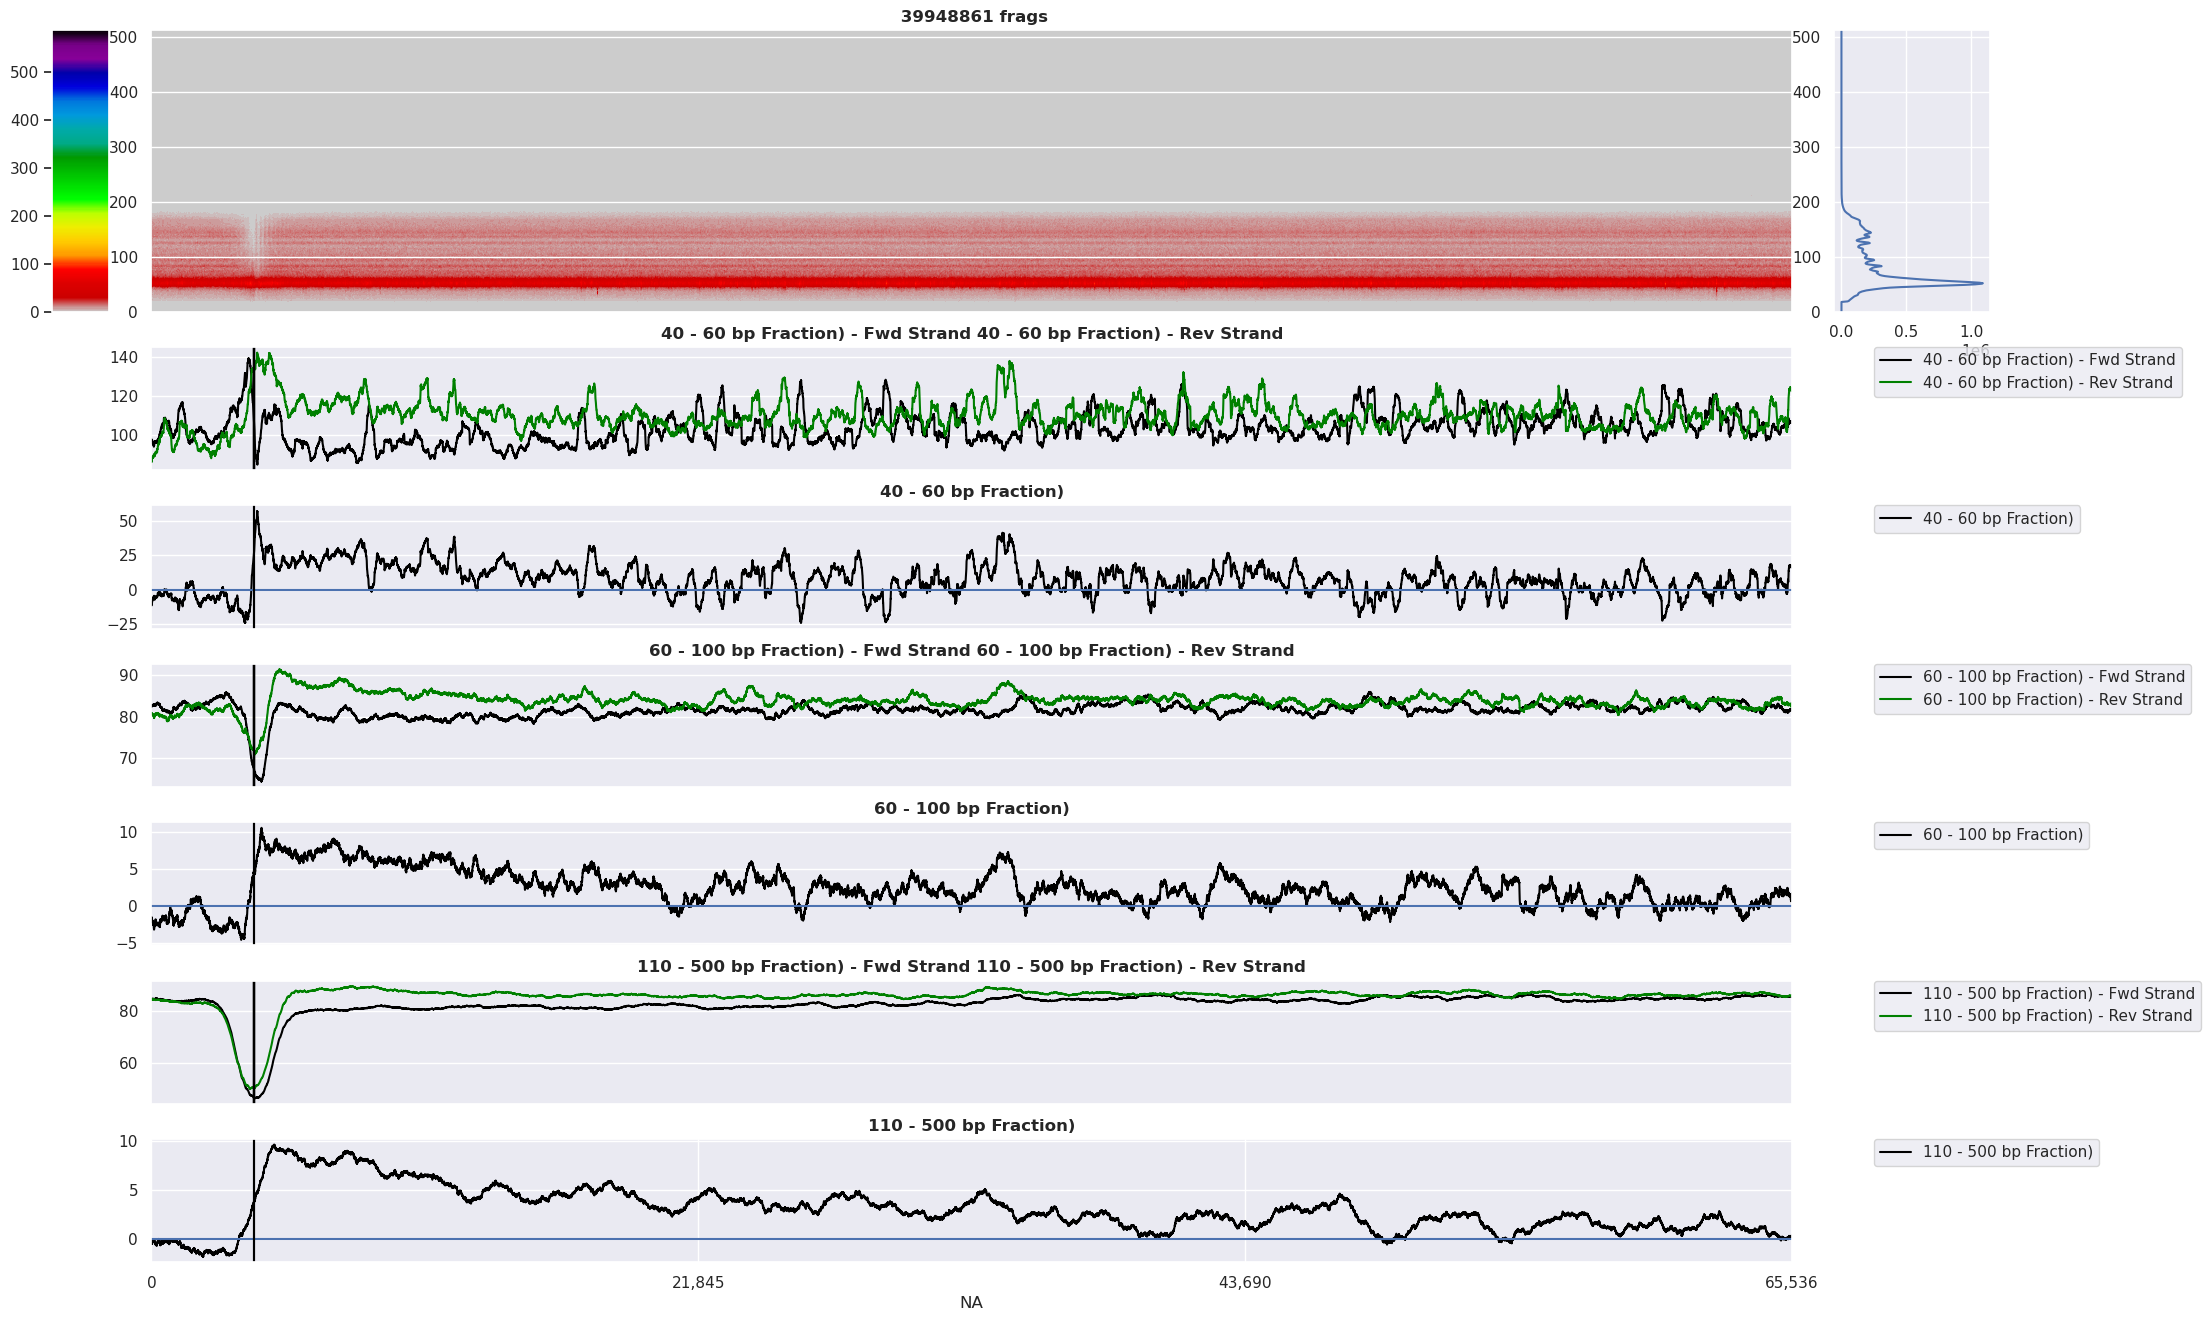

In [524]:
make_single_strand_tss_tracks(fa, True).plot()

(<Figure size 2500x1600 with 9 Axes>,
 [<AxesSubplot:title={'center':' 39951221 frags'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction) - Fwd Strand 40 - 60 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction)'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction) - Fwd Strand 60 - 100 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction)'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction) - Fwd Strand 110 - 500 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction)'}, xlabel='NA'>])

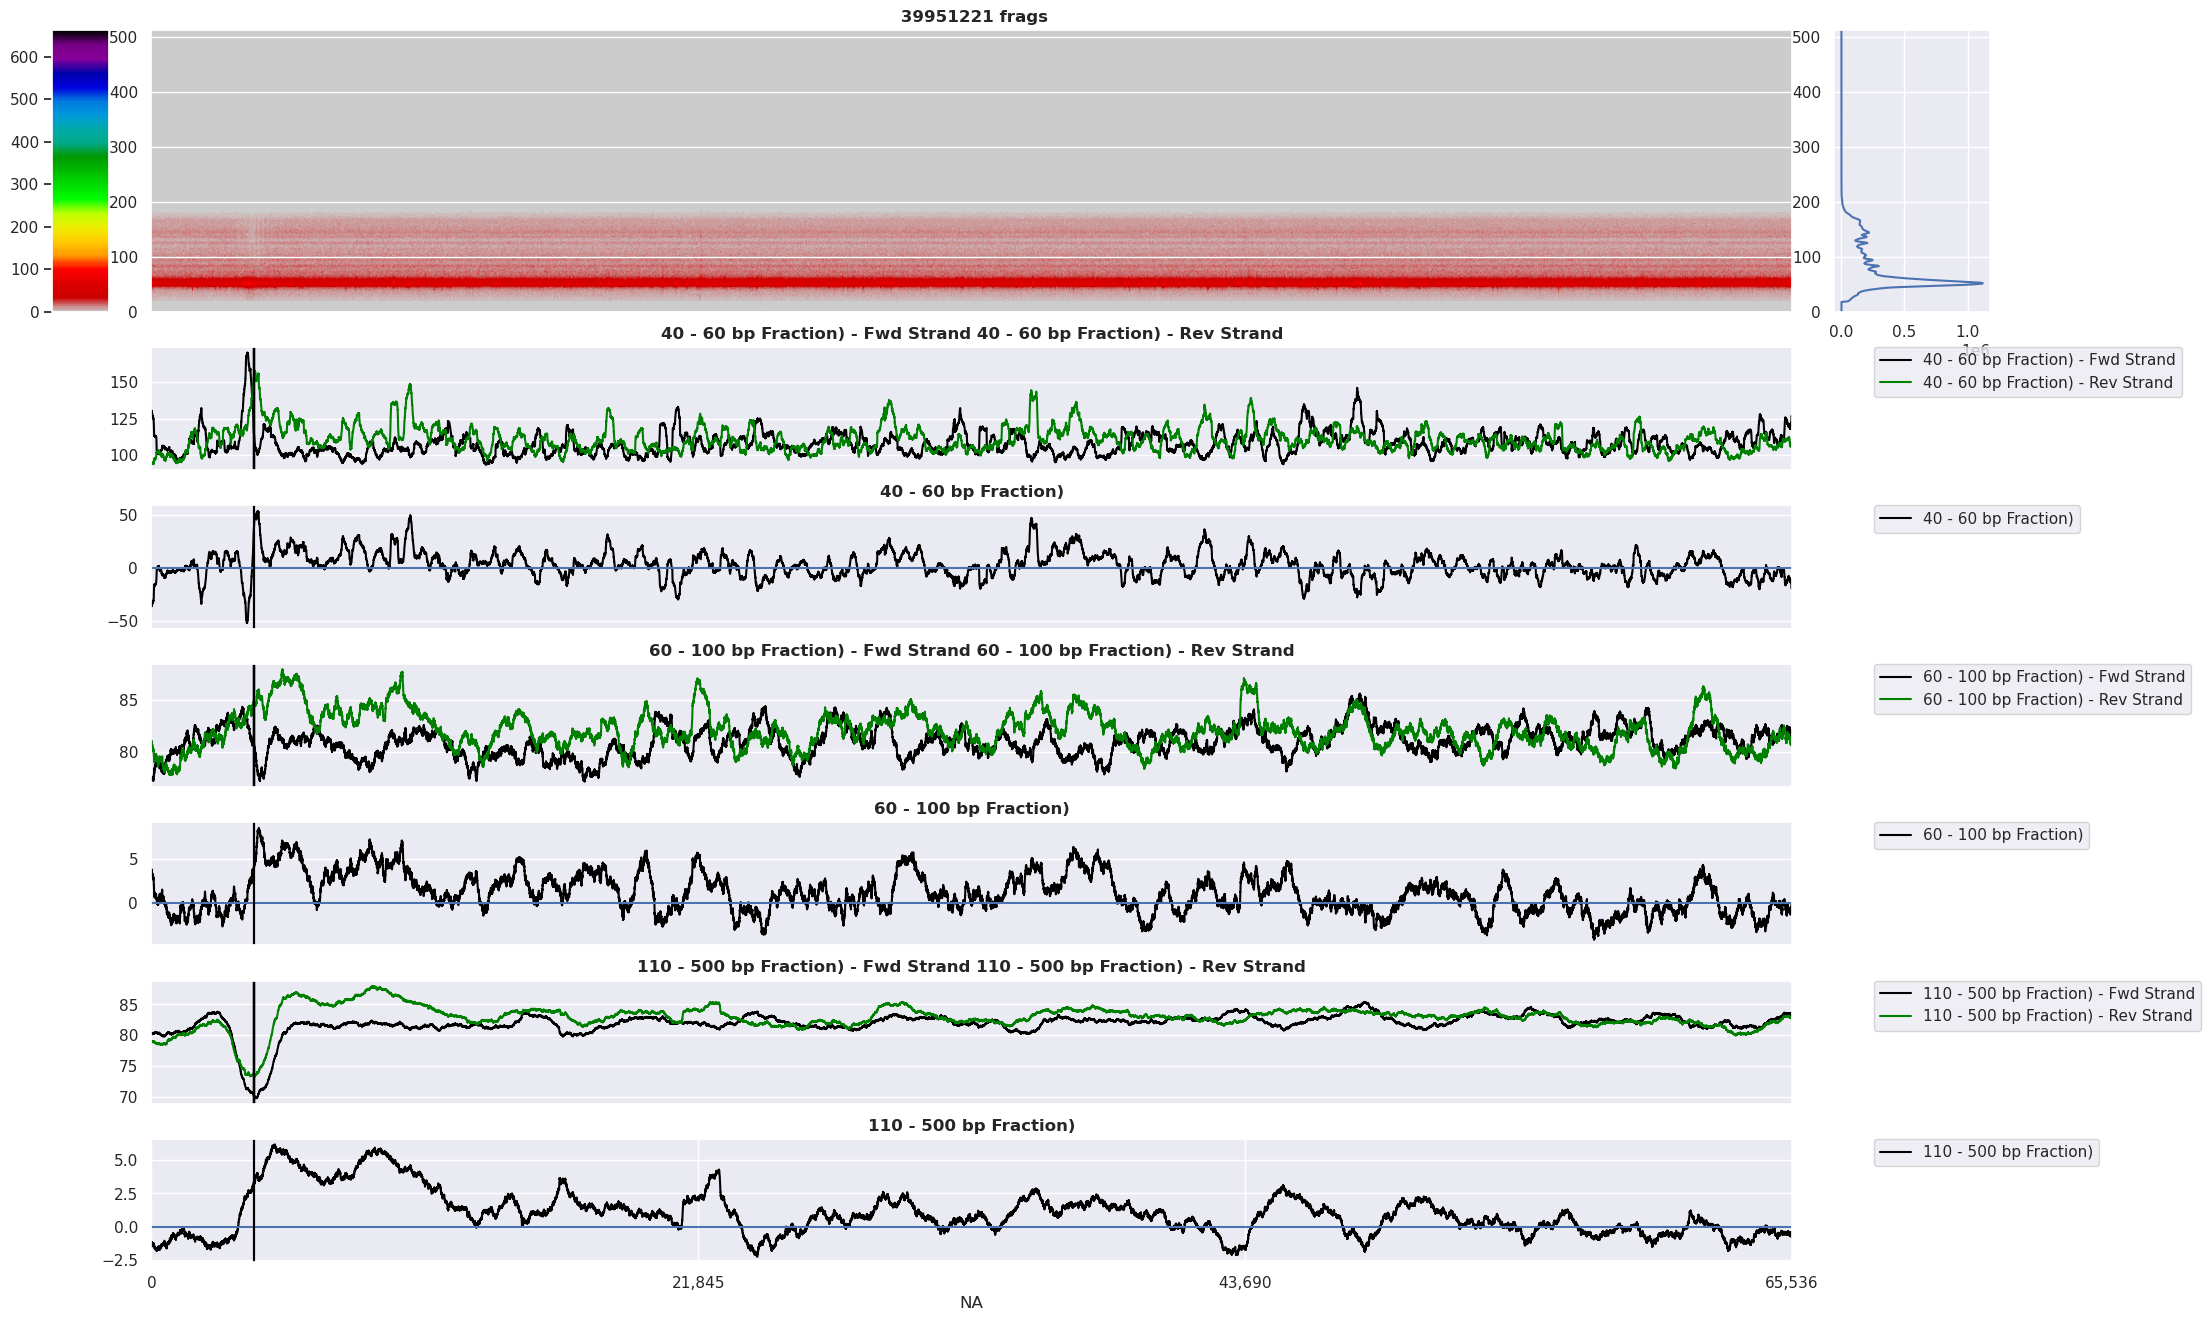

In [525]:
fa = merge_fragment_arrays([_ for _ in df.query("cell_type == 'none' and n_fragments > 100000 and n_fragments < 130000").fa.tolist()]).downsampled(40000000) # cell_type == 'all' and 
make_single_strand_tss_tracks(fa, True).plot()

In [181]:
pd.DataFrame([.truncate(1024)fm.length for fm in fms]).hist(bins=100)

SyntaxError: invalid syntax (1376398094.py, line 1)

(<Figure size 2500x200 with 1 Axes>,
 [<AxesSubplot:title={'center':'coverage'}, xlabel='NA'>])

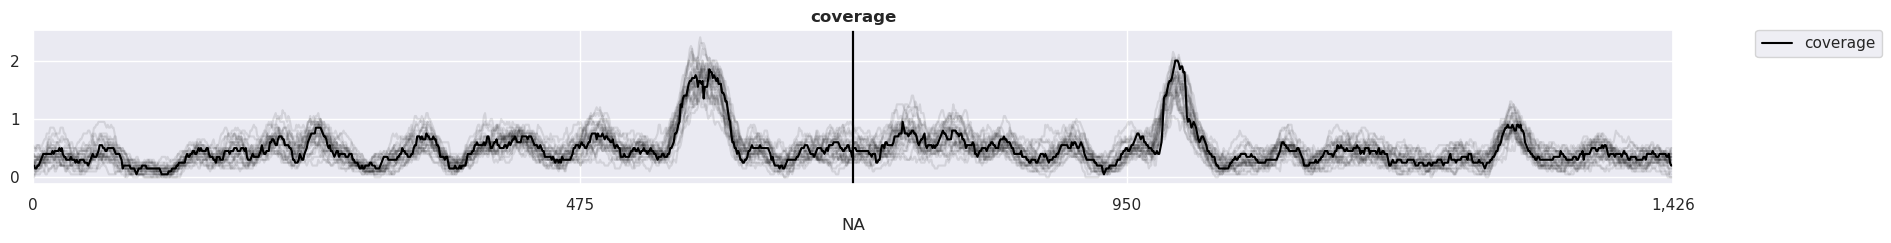

In [423]:
import scipy
tracks = fms[100].make_tracks()
del tracks[0]
tracks.plot()

In [282]:
df.query("strand == '+' and element == 'exon'")

,start,stop
gene_id,,
ENSG00000000005,"[100584936, 100585231, 100593895, 100594261, 1...","[100585066, 100585362, 100594035, 100594362, 1..."
ENSG00000000460,"[169794730, 169795040, 169795043, 169795409, 1...","[169794905, 169795115, 169795213, 169795983, 1..."
ENSG00000000971,"[196652043, 196652045, 196652056, 196672978, 1...","[196652175, 196652175, 196652175, 196673163, 1..."
ENSG00000001167,"[41072974, 41072983, 41079029, 41079029, 41080...","[41073084, 41073084, 41079164, 41079164, 41080..."
ENSG00000001461,"[24415802, 24415803, 24415813, 24415814, 24419...","[24415904, 24415904, 24415904, 24415904, 24419..."
...,...,...
ENSG00000289282,"[31623874, 31624261, 31624450, 31625171, 31625...","[31623909, 31624360, 31624522, 31625314, 31625..."
ENSG00000289325,[66926308],[66926346]
ENSG00000289360,[105040848],[105040925]


In [270]:
df.query("gene_id == 'ENSG00000289281'")

,contig,element,start,stop,strand,gene_id
1228392,chr16,exon,3004132,3004601,+,ENSG00000289281
1228398,chr16,five_prime_UTR,3004132,3004240,+,ENSG00000289281
1228395,chr16,exon,3004603,3004859,+,ENSG00000289281
